# Gemma 4 E4B LoRA / QLoRA 실험

Magicoder + OSS-Instruct 데이터로 Gemma 4 E4B를 instruction-tuning 하는 실험 기록.  
1차 시도(BF16 + LoRA)에서 메모리/품질 이슈를 겪고 2차로 QLoRA(4-bit) + 큐레이션된 OSS-Instruct로 전환한 흐름이 그대로 남아 있다.

## 목차
1. 환경 세팅
2. 데이터 준비 — Magicoder
3. 토크나이저 & Chat Template
4. 포맷 변환 & 토큰화
5. 잘린 샘플 처리
6. 테스트 프롬프트 & 데이터 저장
7. 1차 학습 — BF16 + LoRA
8. 학습 실행 & 결과 저장
9. 추론 — LoRA (Thinking ON)
10. 진단 & 4-way 비교
11. 데이터 큐레이션 v2 — OSS-Instruct
12. 2차 학습 — QLoRA (4-bit)


```
/content/drive/MyDrive/aiffel_gemma_rag/
├── data/
│   ├── instructions/        # LoRA 학습 데이터 (instruction-response pairs)
│   │   ├── train.jsonl
│   │   └── val.jsonl
│   └── 
│
├── models/
│   ├── base/                # Gemma 4 E4B 원본 (HF 캐시)
│   └── lora_adapters/       # LoRA 가중치만 저장 (가벼움, ~수십MB)
│       ├── checkpoint-100/
│       ├── checkpoint-200/
│       └── final/
│
├── vector_db/               # 임베딩 벡터 DB (Day 2)
│   └── chroma_db/
│
├── results/
│   ├── day1_lora/
│   │   ├── training_log.json
│   │   ├── eval_samples.md  # 정성 평가 비교
│   │   └── perplexity.csv
│   └── day2_rag/
│       ├── comparison_results.md  # 3-way 비교
│       └── retrieval_metrics.csv
│
├── notebooks/
│   ├── day1_lora_training.ipynb
│   ├── day2_rag_system.ipynb
│   └── data_preparation.ipynb
│
└── reports/
    └── final_report.md
```

## 1. 환경 세팅

패키지 설치, Drive 마운트, 폴더 구조 생성, HF 캐시 경로 지정.


In [ ]:
# Cell 1: 패키지 재설치
!pip install -U transformers peft accelerate bitsandbytes torchao trl datasets sentence-transformers chromadb

# 버전 확인
import transformers, peft, torch
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print(f"torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}, {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 134.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

transformers: 5.9.0
peft: 0.19.1
torch: 2.10.0+cu128
CUDA: True, NVIDIA L4


In [ ]:
# Cell 2: Drive 마운트 + 폴더 구조 생성
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"

dirs = [
    "data/instructions",
    "data/corpus",
    "models/base",
    "models/lora_adapters",
    "vector_db",
    "results/day1_lora",
    "results/day2_rag",
    "notebooks",
    "reports"
]

for d in dirs:
    os.makedirs(f"{BASE}/{d}", exist_ok=True)

%cd $BASE
!ls -la

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/aiffel_gemma_rag
total 29
-rw------- 1 root root 4260 May 20 13:22 '=4.50'
drwx------ 4 root root 4096 May 20 08:54  data
drwx------ 4 root root 4096 May 20 08:54  models
drwx------ 2 root root 4096 May 20 08:54  notebooks
drwx------ 2 root root 4096 May 20 08:54  reports
drwx------ 4 root root 4096 May 20 08:54  results
drwx------ 2 root root 4096 May 20 08:54  vector_db


In [ ]:
# Cell 3: HF 캐시 위치 지정 + 패키지 설치
os.environ["HF_HOME"] = f"{BASE}/models/base"

!pip install -q transformers peft bitsandbytes accelerate trl datasets sentence-transformers chromadb

## 2. 데이터 준비 — Magicoder 다운로드 & 분석

Magicoder-Evol-Instruct-110K 로드, 길이 분포 확인, subset 추출(길이 필터 + 다양성).


In [ ]:
# Cell 4: Magicoder 데이터셋 다운로드 + 살펴보기
from datasets import load_dataset

ds = load_dataset("ise-uiuc/Magicoder-Evol-Instruct-110K")
print(f"전체 크기: {len(ds['train'])}")
print(f"\n샘플 구조:")
print(ds['train'][0])
print(f"\n필드: {ds['train'].column_names}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the latest cached version of the dataset since ise-uiuc/Magicoder-Evol-Instruct-110K couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /content/drive/MyDrive/aiffel_gemma_rag/models/base/datasets/ise-uiuc___magicoder-evol-instruct-110_k/default/0.0.0/b0079beaa0361d82412520b873715bee59cc7dd4 (last modified on Wed May 20 09:42:23 2026).


전체 크기: 111183

샘플 구조:
{'instruction': "Please amend the subsequent Python script so that it includes a 'while' loop rather than the existing 'for' loop, which iterates through the items of an integer list.\n\nThe script currently has a bug where it attempts to print an object that is outside the bounds of the list. Fix this error and modify the script to use 'while' instead of 'for' loop. Ensure your script correctly handles empty lists. \n\n```python\n  # Establish an integer list\n  arr = [1, 2, 3, 4]\n\n  # Determine the length of the list\n  n = len(arr)\n\n  # Traverse the list and output each individual element\n  for i in range(n+1):\n      print(arr[i])\n```", 'response': '```python\n# Establish an integer list\narr = [1, 2, 3, 4]\n\n# Determine the length of the list\nn = len(arr)\n\n# Initialize index at 0\ni = 0\n\n# Traverse the list and output each individual element\nwhile i < n:\n    print(arr[i])\n    i += 1\n```\nIn the given code, it tries to access `arr[n]` which is 

In [ ]:
# Cell 5: 길이 분포 분석
import numpy as np

# 토큰 길이 대신 일단 문자 길이로 빠르게 확인
inst_lens = [len(x['instruction']) for x in ds['train']]
resp_lens = [len(x['response']) for x in ds['train']]
total_lens = [i + r for i, r in zip(inst_lens, resp_lens)]

print("=== Instruction 길이 (chars) ===")
print(f"min: {min(inst_lens)}, max: {max(inst_lens)}")
print(f"mean: {np.mean(inst_lens):.0f}, median: {np.median(inst_lens):.0f}")
print(f"percentiles 50/75/90/95/99: {np.percentile(inst_lens, [50, 75, 90, 95, 99])}")

print("\n=== Response 길이 (chars) ===")
print(f"min: {min(resp_lens)}, max: {max(resp_lens)}")
print(f"mean: {np.mean(resp_lens):.0f}, median: {np.median(resp_lens):.0f}")
print(f"percentiles 50/75/90/95/99: {np.percentile(resp_lens, [50, 75, 90, 95, 99])}")

print("\n=== Total 길이 (chars) ===")
print(f"min: {min(total_lens)}, max: {max(total_lens)}")
print(f"mean: {np.mean(total_lens):.0f}, median: {np.median(total_lens):.0f}")
print(f"percentiles 50/75/90/95/99: {np.percentile(total_lens, [50, 75, 90, 95, 99])}")

=== Instruction 길이 (chars) ===
min: 1, max: 27712
mean: 653, median: 397
percentiles 50/75/90/95/99: [ 397.    737.   1245.   1775.   3614.36]

=== Response 길이 (chars) ===
min: 100, max: 7646
mean: 1552, median: 1461
percentiles 50/75/90/95/99: [1461.   1993.   2599.   2999.   3663.18]

=== Total 길이 (chars) ===
min: 142, max: 30369
mean: 2205, median: 1980
percentiles 50/75/90/95/99: [1980. 2702. 3561. 4236. 6130.]


In [ ]:
# Cell 6: Subset 추출 (길이 필터 + 다양성)

# 1. 너무 긴 샘플 제거 (95 percentile 이상)
def is_reasonable(example):
    total_len = len(example['instruction']) + len(example['response'])
    return total_len < 4500  # 95 percentile 근처

filtered = ds['train'].filter(is_reasonable)
print(f"필터링 후: {len(filtered)} (원본 {len(ds['train'])}에서 {len(ds['train']) - len(filtered)}개 제거)")

# 2. 1K 무작위 추출 (재현성 위해 seed 고정)
small = filtered.shuffle(seed=42).select(range(1000))

# 3. Train/Val 분리 (LoRA는 적은 val로도 충분)
small_split = small.train_test_split(test_size=0.1, seed=42)
train_data = small_split['train']  # 900개
val_data = small_split['test']     # 100개

print(f"\nTrain: {len(train_data)}")
print(f"Val:   {len(val_data)}")

# 4. 길이 분포 다시 확인 (subset이 원본과 비슷한지)
import numpy as np
sub_total = [len(x['instruction']) + len(x['response']) for x in train_data]
print(f"\nSubset total 길이 percentiles 50/90/95/99: {np.percentile(sub_total, [50, 90, 95, 99])}")

필터링 후: 106812 (원본 111183에서 4371개 제거)

Train: 900
Val:   100

Subset total 길이 percentiles 50/90/95/99: [1983.5 3310.7 3772.8 4287. ]


## 3. 토크나이저 & Chat Template

Transformers 업그레이드, Gemma 4 E4B 토크나이저 로드, chat template 동작 테스트.


In [ ]:
# Cell 7: Transformers 버전 확인 + 업그레이드
import transformers
print(f"현재 transformers: {transformers.__version__}")

# Gemma 4 지원 버전 (대략 4.50+ 필요할 듯)
# 만약 너무 낮으면 업그레이드
!pip install -U transformers>=4.50

현재 transformers: 5.8.1


In [ ]:
# Cell 8: Gemma 4 E4B 토크나이저 다운로드
from transformers import AutoTokenizer

MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.special_tokens_map}")
print(f"Chat template 있음: {tokenizer.chat_template is not None}")
print(f"Chat template (앞 500자):\n{tokenizer.chat_template[:500] if tokenizer.chat_template else 'None'}")

Vocab size: 262144
Special tokens: {'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'mask_token': '<mask>', 'audio_token': '<|audio|>', 'boa_token': '<|audio>', 'boi_token': '<|image>', 'eoa_token': '<audio|>', 'eoc_token': '<channel|>', 'eoi_token': '<image|>', 'eot_token': '<turn|>', 'escape_token': '<|"|>', 'etc_token': '<tool_call|>', 'etd_token': '<tool|>', 'etr_token': '<tool_response|>', 'image_token': '<|image|>', 'soc_token': '<|channel>', 'sot_token': '<|turn>', 'stc_token': '<|tool_call>', 'std_token': '<|tool>', 'str_token': '<|tool_response>', 'think_token': '<|think|>'}
Chat template 있음: True
Chat template (앞 500자):
{%- macro format_parameters(properties, required, filter_keys=false) -%}
    {%- set standard_keys = ['description', 'type', 'properties', 'required', 'nullable'] -%}
    {%- set ns = namespace(found_first=false) -%}
    {%- for key, value in properties | dictsort -%}
        {%- set add_comma = false -%}
        {%- if 

In [ ]:
# Cell 9: Chat template 동작 테스트
messages = [
    {"role": "user", "content": "Write a Python function to reverse a string."},
    {"role": "assistant", "content": "Here's a function:\n```python\ndef reverse_string(s):\n    return s[::-1]\n```"}
]

formatted = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False
)
print("=== Formatted text ===")
print(formatted)
print(f"\n=== Token count: {len(tokenizer.encode(formatted))} ===")

=== Formatted text ===
<bos><|turn>user
Write a Python function to reverse a string.<turn|>
<|turn>model
Here's a function:
```python
def reverse_string(s):
    return s[::-1]
```<turn|>


=== Token count: 46 ===


## 4. 포맷 변환 & 토큰화

Magicoder를 Gemma 4 chat 포맷으로 변환, 실제 토큰 길이 분포 측정, MAX_LENGTH=768로 토큰화.


In [ ]:
# Cell 10: Magicoder → Gemma 4 chat format 변환

def format_example(example):
    messages = [
        {"role": "user", "content": example['instruction']},
        {"role": "assistant", "content": example['response']}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

# Train, val 모두 변환
train_formatted = train_data.map(format_example, remove_columns=train_data.column_names)
val_formatted = val_data.map(format_example, remove_columns=val_data.column_names)

# 샘플 확인
print("=== Train sample (first 1000 chars) ===")
print(train_formatted[0]['text'][:1000])
print(f"\nTrain size: {len(train_formatted)}, Val size: {len(val_formatted)}")

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

=== Train sample (first 1000 chars) ===
<bos><|turn>user
port the below code to rust:
def count_upper(s):
    """
    count_upper('aBCdEfG') returns 2
    count_upper('ABCDEF') returns 3
    count_upper('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ') returns 5
    """
    assert 1 <= len(s) <= 1000, "String length should be between 1 and 1000 characters"
    
    vow = ['A', 'E', 'I', 'O', 'U']
    count = sum(1 for i in range(len(s)) if i % 2 == 0 and s[i] in vow)
    
    return count<turn|>
<|turn>model
Here is a version of the program in Rust:

```rust
pub fn count_upper(s: &str) -> i32 {
    assert!(1 <= s.len() && s.len() <= 1000, "String length should be between 1 and 1000 characters");

    let vow = ['A', 'E', 'I', 'O', 'U'];
    let count = s.chars().enumerate().filter(|(i, c)| i % 2 == 0 && vow.contains(c)).count();

    count as i32
}
```

This code does as follows:
- Takes a string slice `s` as input.
- Checks if the length of the string is between 1 and 1000 inclu

In [ ]:
# Cell 11: 실제 토큰 길이 분포
import numpy as np

# Train 데이터의 토큰 길이 측정
train_token_lens = []
for example in train_formatted:
    tokens = tokenizer.encode(example['text'])
    train_token_lens.append(len(tokens))

train_token_lens = np.array(train_token_lens)

print("=== Train 토큰 길이 분포 ===")
print(f"min: {train_token_lens.min()}")
print(f"max: {train_token_lens.max()}")
print(f"mean: {train_token_lens.mean():.0f}")
print(f"median: {np.median(train_token_lens):.0f}")
print(f"percentiles 50/75/90/95/99: {np.percentile(train_token_lens, [50, 75, 90, 95, 99])}")

# Val도 같이
val_token_lens = [len(tokenizer.encode(x['text'])) for x in val_formatted]
val_token_lens = np.array(val_token_lens)
print(f"\n=== Val 토큰 길이 분포 ===")
print(f"max: {val_token_lens.max()}, mean: {val_token_lens.mean():.0f}, 95%: {np.percentile(val_token_lens, 95):.0f}")

=== Train 토큰 길이 분포 ===
min: 66
max: 3460
mean: 569
median: 516
percentiles 50/75/90/95/99: [ 516.    677.25  867.   1036.05 2278.62]

=== Val 토큰 길이 분포 ===
max: 2270, mean: 563, 95%: 975


In [ ]:
# Cell 12: 토큰화

MAX_LENGTH = 768

def tokenize_short(example):
    return tokenizer(
        example['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

train_tokenized = train_formatted.map(
    tokenize,
    batched=True,
    remove_columns=['text']
)
val_tokenized = val_formatted.map(
    tokenize,
    batched=True,
    remove_columns=['text']
)

print(f"Train tokenized: {len(train_tokenized)}")
print(f"Val tokenized: {len(val_tokenized)}")
print(f"\nSample (first):")
print(f"  input_ids 길이: {len(train_tokenized[0]['input_ids'])}")
print(f"  처음 20개 토큰: {train_tokenized[0]['input_ids'][:20]}")
print(f"  디코드: {tokenizer.decode(train_tokenized[0]['input_ids'][:50])}")

# 잘린 비율 확인
truncated = sum(1 for x in train_tokenized if len(x['input_ids']) == MAX_LENGTH)
print(f"\nMax length 도달 (잘렸을 가능성): {truncated}/{len(train_tokenized)} = {truncated/len(train_tokenized)*100:.1f}%")

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Train tokenized: 900
Val tokenized: 100

Sample (first):
  input_ids 길이: 422
  처음 20개 토큰: [2, 105, 2364, 107, 728, 506, 3426, 3393, 531, 16432, 236787, 107, 2063, 1527, 236779, 26846, 236769, 236751, 1473, 107]
  디코드: <bos><|turn>user
port the below code to rust:
def count_upper(s):
    """
    count_upper('aBCdEfG') returns 2
    count_upper('ABCDEF') returns 3


Max length 도달 (잘렸을 가능성): 150/900 = 16.7%


## 5. 잘린 샘플 처리

MAX_LENGTH에 잘린 샘플 검사하고 필터링.


In [ ]:
# Cell 13a: 잘린 샘플 검사
truncated_indices = [i for i, x in enumerate(train_tokenized) if len(x['input_ids']) == MAX_LENGTH]
print(f"잘린 샘플 수: {len(truncated_indices)}")
print(f"\n=== 첫 번째 잘린 샘플의 끝 부분 (마지막 200 토큰) ===")
sample = train_tokenized[truncated_indices[0]]
print(tokenizer.decode(sample['input_ids'][-200:]))

잘린 샘플 수: 46

=== 첫 번째 잘린 샘플의 끝 부분 (마지막 200 토큰) ===
path d="M21 15.25C21 15.1655 21.0046 15.0821 21.0137 15H25.4863C25.4954 15.0821 25.5 15.1655 25.5 15.25C25.5 16.4945 24.4945 17.5 23.25 17.5C22.0055 17.49 21 16.4845 21 15.25Z" fill="#402A32"/>
<path d="M8.06915 9.9876


In [ ]:
# Cell 13b: 잘린 샘플 필터링
def is_not_truncated(example):
    return len(example['input_ids']) < MAX_LENGTH

train_clean = train_tokenized.filter(is_not_truncated)
val_clean = val_tokenized.filter(is_not_truncated)

print(f"Train: {len(train_tokenized)} → {len(train_clean)} ({len(train_tokenized) - len(train_clean)}개 제거)")
print(f"Val: {len(val_tokenized)} → {len(val_clean)} ({len(val_tokenized) - len(val_clean)}개 제거)")

Filter:   0%|          | 0/900 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Train: 900 → 854 (46개 제거)
Val: 100 → 97 (3개 제거)


## 6. 테스트 프롬프트 정의 & 데이터 저장

8문제 평가 세트(TEST_PROMPTS) 정의. `train_filtered` / `val_filtered` 경로에 데이터 저장 (구 경로 저장 셀은 정리하면서 제거).


In [ ]:
TEST_PROMPTS = [
    # === 난이도 하 (Vanilla도 어느 정도 풀 수 있음) ===
    {
        "category": "basic_feature",
        "difficulty": "easy",
        "prompt": "Implement a Python function that reads a CSV file and returns a list of dictionaries, where each row becomes a dictionary with column names as keys."
    },
    {
        "category": "basic_feature",
        "difficulty": "easy",
        "prompt": "Write a function that takes a nested dictionary and flattens it. Keys should be joined with dots. e.g., {'a': {'b': 1}} → {'a.b': 1}"
    },

    # === 난이도 중 (LoRA 효과 가장 잘 보일 영역) ===
    {
        "category": "system_feature",
        "difficulty": "medium",
        "prompt": "Implement a thread-safe LRU cache in Python with a configurable maximum size. Include get and put methods."
    },
    {
        "category": "system_feature",
        "difficulty": "medium",
        "prompt": "Write a Python rate limiter using the token bucket algorithm. It should support different rate limits per user."
    },
    {
        "category": "system_feature",
        "difficulty": "medium",
        "prompt": "Implement a simple URL shortener service. Include functions to encode a long URL to a short code, decode it back, and handle collisions."
    },

    # === 난이도 상 (둘 다 어려워하지만 LoRA가 더 잘할 수도) ===
    {
        "category": "complex_feature",
        "difficulty": "hard",
        "prompt": "Implement a basic publish-subscribe pattern in Python with topic-based routing. Include subscribe, unsubscribe, and publish methods. Support wildcards in topic names (e.g., 'events.*' subscribes to all events.X topics)."
    },
    {
        "category": "complex_feature",
        "difficulty": "hard",
        "prompt": "Write a Python function to detect cycles in a directed graph and return the cycle if found. The graph is represented as an adjacency list."
    },

    # === 한국어 능력 보존 확인 ===
    {
        "category": "korean",
        "difficulty": "medium",
        "prompt": "Python으로 간단한 캐시 시스템을 구현해줘. TTL(Time To Live) 기능을 포함하고, 만료된 항목은 자동으로 삭제되어야 해."
    },
]

In [ ]:
# Cell 15 수정: 다른 경로에 저장
import json

# 새 경로에 저장 (filtered 버전)
train_clean.save_to_disk(f"{BASE}/data/instructions/train_filtered")
val_clean.save_to_disk(f"{BASE}/data/instructions/val_filtered")

# 테스트 프롬프트
TEST_PROMPTS = [
    {"category": "basic_feature", "difficulty": "easy",
     "prompt": "Implement a Python function that reads a CSV file and returns a list of dictionaries, where each row becomes a dictionary with column names as keys."},
    {"category": "basic_feature", "difficulty": "easy",
     "prompt": "Write a function that takes a nested dictionary and flattens it. Keys should be joined with dots. e.g., {'a': {'b': 1}} → {'a.b': 1}"},
    {"category": "system_feature", "difficulty": "medium",
     "prompt": "Implement a thread-safe LRU cache in Python with a configurable maximum size. Include get and put methods."},
    {"category": "system_feature", "difficulty": "medium",
     "prompt": "Write a Python rate limiter using the token bucket algorithm. It should support different rate limits per user."},
    {"category": "system_feature", "difficulty": "medium",
     "prompt": "Implement a simple URL shortener service. Include functions to encode a long URL to a short code, decode it back, and handle collisions."},
    {"category": "complex_feature", "difficulty": "hard",
     "prompt": "Implement a basic publish-subscribe pattern in Python with topic-based routing. Include subscribe, unsubscribe, and publish methods. Support wildcards in topic names (e.g., 'events.*' subscribes to all events.X topics)."},
    {"category": "complex_feature", "difficulty": "hard",
     "prompt": "Write a Python function to detect cycles in a directed graph and return the cycle if found. The graph is represented as an adjacency list."},
    {"category": "korean", "difficulty": "medium",
     "prompt": "Python으로 간단한 캐시 시스템을 구현해줘. TTL(Time To Live) 기능을 포함하고, 만료된 항목은 자동으로 삭제되어야 해."},
]

with open(f"{BASE}/data/test_prompts.json", "w", encoding="utf-8") as f:
    json.dump(TEST_PROMPTS, f, ensure_ascii=False, indent=2)

# 베이스라인 점수
BASELINE_SCORES = {
    "csv": {"correctness": 7, "efficiency": 7, "readability": 6, "edge_cases": 4, "total": 24, "ratio": 0.60},
    "dict_flatten": {"correctness": 7, "efficiency": 7, "readability": 7, "edge_cases": 3, "total": 24, "ratio": 0.60},
    "lru_cache": {"correctness": 7, "efficiency": 8, "readability": 7, "edge_cases": 6, "total": 28, "ratio": 0.70},
    "rate_limiter": {"correctness": 7, "efficiency": 8, "readability": 7, "edge_cases": 5, "total": 27, "ratio": 0.675},
    "url_shortener": {"correctness": 4, "efficiency": 7, "readability": 6, "edge_cases": 3, "total": 20, "ratio": 0.50},
    "pubsub": {"correctness": 3, "efficiency": 5, "readability": 3, "edge_cases": 4, "total": 15, "ratio": 0.375},
    "graph_cycle": {"correctness": 8, "efficiency": 7, "readability": 8, "edge_cases": 7, "total": 30, "ratio": 0.75},
    "ttl_cache": {"correctness": 6, "efficiency": 6, "readability": 5, "edge_cases": 4, "total": 21, "ratio": 0.525},
}

with open(f"{BASE}/results/day1_lora/baseline_scores.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_SCORES, f, ensure_ascii=False, indent=2)

print("저장 완료")
print(f"\nTrain: {len(train_clean)}, Val: {len(val_clean)}")
print(f"평균 베이스라인: {sum(s['ratio'] for s in BASELINE_SCORES.values())/len(BASELINE_SCORES)*100:.1f}%")
!ls -la $BASE/data/instructions/

Saving the dataset (0/1 shards):   0%|          | 0/854 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/97 [00:00<?, ? examples/s]

저장 완료

Train: 854, Val: 97
평균 베이스라인: 59.1%
total 20
drwx------ 2 root root 4096 May 20 13:27 magicoder_subset_raw
drwx------ 2 root root 4096 May 20 13:31 train_clean
drwx------ 2 root root 4096 May 20 13:32 train_filtered
drwx------ 2 root root 4096 May 20 13:31 val_clean
drwx------ 2 root root 4096 May 20 13:32 val_filtered


## 7. 1차 학습 — BF16 + LoRA

GPU 재시작 후 모델 로드(BF16), torchao 업데이트, LoRA config(42 layers × 4 proj), length 컬럼 추가, 메모리 최적화 TrainingArguments.


In [ ]:
# Cell A: GPU 재시작 후 첫 셀들

# 1. Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"

# 2. nvidia-smi 확인 (GPU 켜졌나)
!nvidia-smi

# 3. 패키지 (재설치 필요할 수 있음)
!pip install -q transformers peft bitsandbytes accelerate trl datasets sentence-transformers chromadb

# 4. 데이터 로드
from datasets import load_from_disk
train_clean = load_from_disk(f"{BASE}/data/instructions/train_filtered")
val_clean = load_from_disk(f"{BASE}/data/instructions/val_filtered")

import json
with open(f"{BASE}/data/test_prompts.json", "r", encoding="utf-8") as f:
    TEST_PROMPTS = json.load(f)

print(f"Train: {len(train_clean)}, Val: {len(val_clean)}")
print(f"Test prompts: {len(TEST_PROMPTS)}")

# 5. 토크나이저 다시 로드
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wed May 20 13:33:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|          

In [ ]:
# Cell 16: Gemma 4 E4B 모델 로드 (BF16)
import torch
from transformers import AutoModelForCausalLM

print("모델 로드 중... (16GB, 첫 다운로드는 5~10분 걸림)")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",  # GPU에 자동 배치
)

# 모델 정보
print(f"\n모델 클래스: {type(model).__name__}")
print(f"총 파라미터: {model.num_parameters():,}")
print(f"학습 가능 파라미터: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"디바이스: {next(model.parameters()).device}")
print(f"Dtype: {next(model.parameters()).dtype}")

# VRAM 사용량
print(f"\nGPU 메모리:")
print(f"  할당됨: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  예약됨: {torch.cuda.memory_reserved()/1e9:.2f} GB")

모델 로드 중... (16GB, 첫 다운로드는 5~10분 걸림)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]


모델 클래스: Gemma4ForConditionalGeneration
총 파라미터: 7,941,100,832
학습 가능 파라미터: 7,941,100,832
디바이스: cuda:0
Dtype: torch.bfloat16

GPU 메모리:
  할당됨: 15.88 GB
  예약됨: 16.12 GB


In [ ]:
# Cell: torchao 업데이트
!pip install -U torchao
import torchao
print(f"torchao: {torchao.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


torchao: 0.17.0


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
import torch

# 명시적 target modules 생성 (42 layers × 7 projections = 294개)
target_modules = []
for i in range(42):
    for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj']:
        target_modules.append(f"model.language_model.layers.{i}.self_attn.{proj}")
    for proj in ['gate_proj', 'up_proj', 'down_proj']:
        target_modules.append(f"model.language_model.layers.{i}.mlp.{proj}")

print(f"Target modules 수: {len(target_modules)}")
print(f"첫 몇 개: {target_modules[:3]}")

# LoRA Config
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# 적용
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

print(f"\nGPU 메모리:")
print(f"  할당됨: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  예약됨: {torch.cuda.memory_reserved()/1e9:.2f} GB")

Target modules 수: 294
첫 몇 개: ['model.language_model.layers.0.self_attn.q_proj', 'model.language_model.layers.0.self_attn.k_proj', 'model.language_model.layers.0.self_attn.v_proj']
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373

GPU 메모리:
  할당됨: 16.02 GB
  예약됨: 16.26 GB


In [ ]:
# Cell 18-pre: length 컬럼 추가
def add_length(example):
    return {"length": len(example["input_ids"])}

train_clean = train_clean.map(add_length)
val_clean = val_clean.map(add_length)

print(f"Train columns: {train_clean.column_names}")
print(f"Length 분포 (sample):")
import numpy as np
lengths = [x['length'] for x in train_clean]
print(f"  min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.0f}")

Map:   0%|          | 0/854 [00:00<?, ? examples/s]

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

Train columns: ['input_ids', 'attention_mask', 'length']
Length 분포 (sample):
  min: 66, max: 1023, mean: 510


In [ ]:
# Cell 18-rev: 메모리 최적화된 TrainingArguments
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# 메모리 정리
import torch, gc
del trainer  # 기존 trainer 메모리 해제
gc.collect()
torch.cuda.empty_cache()
print(f"정리 후 GPU 메모리: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# PEFT + gradient checkpointing 활성화
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# TrainingArguments 재설정 (batch_size 줄임)
training_args = TrainingArguments(
    output_dir=f"{BASE}/models/lora_adapters",

    num_train_epochs=2,
    per_device_train_batch_size=1,        # ← 2에서 1로
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,        # ← 4에서 8로 (effective 8 유지)

    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,                      # warmup_ratio 대신

    bf16=True,

    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    logging_steps=10,
    report_to="none",

    gradient_checkpointing=True,
    optim="adamw_torch",
)

# Trainer 재생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_clean,
    eval_dataset=val_clean,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("재구성 완료")
print(f"GPU 메모리: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"\n학습 시작...")
trainer.train()

정리 후 GPU 메모리: 18.22 GB
재구성 완료
GPU 메모리: 18.22 GB

학습 시작...


Step,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 776.00 MiB. GPU 0 has a total capacity of 22.03 GiB of which 747.12 MiB is free. Including non-PyTorch memory, this process has 21.30 GiB memory in use. Of the allocated memory 19.34 GiB is allocated by PyTorch, and 1.72 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 8. 학습 실행 & 결과 저장

Quick Start(재시작 후 학습 직전까지) → 학습 시작 → 학습 후 손실 그래프 → 저장 상태 확인 → training_summary 저장.


In [ ]:
# === Quick Start (재시작 후 이 셀 하나로 학습 직전까지) ===

# 1. 환경
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# 2. 데이터 로드
from datasets import load_from_disk
train_clean = load_from_disk(f"{BASE}/data/instructions/train_filtered")
val_clean = load_from_disk(f"{BASE}/data/instructions/val_filtered")
print(f"Data: train {len(train_clean)}, val {len(val_clean)}")

# 3. 토크나이저
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: vocab {tokenizer.vocab_size}")

# 4. 모델 (BF16, 양자화 없이)
from transformers import AutoModelForCausalLM
print("모델 로드 중... (HF 캐시 있어서 1~2분)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print(f"Model loaded. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# 5. LoRA 설정
from peft import LoraConfig, get_peft_model, TaskType

target_modules = []
for i in range(42):
    for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj']:
        target_modules.append(f"model.language_model.layers.{i}.self_attn.{proj}")
    for proj in ['gate_proj', 'up_proj', 'down_proj']:
        target_modules.append(f"model.language_model.layers.{i}.mlp.{proj}")

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.config.use_cache = False  # ← 학습 중 cache 안 만들기
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.print_trainable_parameters()

print(f"\nReady. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data: train 854, val 97


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Model loaded. GPU: 15.88 GB
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373

Ready. GPU: 16.02 GB


In [ ]:
# === 학습 시작 ===
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=f"{BASE}/models/lora_adapters",
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    bf16=True,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=10,
    report_to="none",
    gradient_checkpointing=True,
    optim="adamw_torch",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_clean,
    eval_dataset=val_clean,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss
50,1.110533,1.208260
100,1.177565,1.181357
150,1.001516,1.178676
200,1.059783,1.178643
214,1.025371,1.178512


TrainOutput(global_step=214, training_loss=1.1461468288831622, metrics={'train_runtime': 1671.2941, 'train_samples_per_second': 1.022, 'train_steps_per_second': 0.128, 'total_flos': 2.342914974482688e+16, 'train_loss': 1.1461468288831622, 'epoch': 2.0})

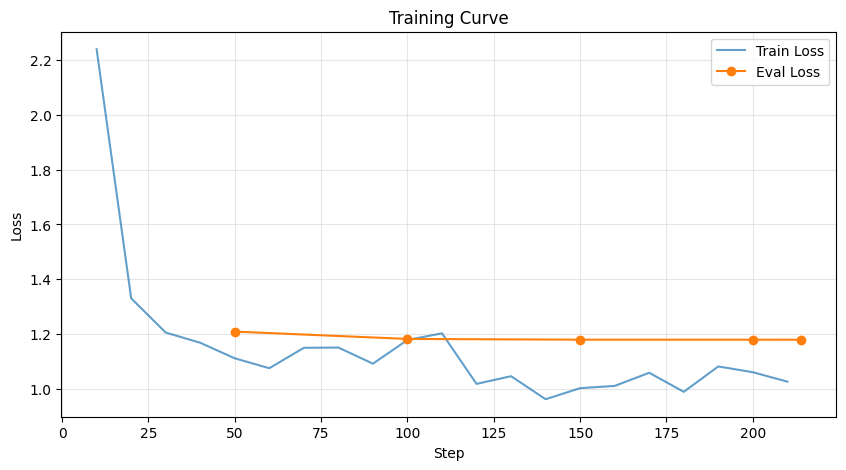

In [ ]:
# 학습 끝난 후 사용할 코드 (지금은 두기만)
import matplotlib.pyplot as plt

# trainer.state.log_history 에 모든 log 있음
logs = trainer.state.log_history
train_logs = [(l['step'], l['loss']) for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_logs = [(l['step'], l['eval_loss']) for l in logs if 'eval_loss' in l]

# 플롯
plt.figure(figsize=(10, 5))
if train_logs:
    steps, losses = zip(*train_logs)
    plt.plot(steps, losses, label='Train Loss', alpha=0.7)
if eval_logs:
    steps, losses = zip(*eval_logs)
    plt.plot(steps, losses, label='Eval Loss', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curve')
plt.grid(alpha=0.3)
plt.savefig(f"{BASE}/results/day1_lora/training_curve.png", dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Cell: 저장 상태 확인 + 명시적 저장
import os

# 자동 저장된 체크포인트 확인
lora_dir = f"{BASE}/models/lora_adapters"
print("=== 저장된 체크포인트 ===")
for item in sorted(os.listdir(lora_dir)):
    full_path = f"{lora_dir}/{item}"
    if os.path.isdir(full_path):
        size_mb = sum(os.path.getsize(f"{full_path}/{f}")
                      for f in os.listdir(full_path)) / 1e6
        print(f"  {item}: {size_mb:.1f} MB")

# 명시적으로 best 모델 저장 (안전)
final_path = f"{lora_dir}/final"
trainer.save_model(final_path)
print(f"\nFinal model saved to: {final_path}")

# Drive 마지막 상태
print("\n=== Final 디렉토리 내용 ===")
!ls -la $final_path

=== 저장된 체크포인트 ===
  checkpoint-100: 451.3 MB
  checkpoint-200: 451.3 MB
  checkpoint-214: 451.3 MB

Final model saved to: /content/drive/MyDrive/aiffel_gemma_rag/models/lora_adapters/final

=== Final 디렉토리 내용 ===
total 167795
-rw------- 1 root root     16633 May 20 14:38 adapter_config.json
-rw------- 1 root root 139602808 May 20 14:38 adapter_model.safetensors
-rw------- 1 root root     17336 May 20 14:38 chat_template.jinja
-rw------- 1 root root      5196 May 20 14:38 README.md
-rw------- 1 root root      2742 May 20 14:38 tokenizer_config.json
-rw------- 1 root root  32169626 May 20 14:38 tokenizer.json
-rw------- 1 root root      5265 May 20 14:38 training_args.bin


In [ ]:
# 학습 결과 저장
import json

training_summary = {
    "epochs": 2,
    "total_steps": 214,
    "batch_size_effective": 8,
    "learning_rate": 2e-4,
    "lora_rank": 16,
    "lora_alpha": 32,
    "trainable_params": 34881536,
    "total_params": 7975982368,
    "trainable_percent": 0.4373,
    "train_runtime_sec": 1671.29,
    "samples_per_second": 1.022,
    "final_train_loss": 1.146,
    "final_eval_loss": 1.179,
    "train_loss_curve": [(50, 1.110533), (100, 1.177565), (150, 1.001516), (200, 1.059783), (214, 1.025371)],
    "eval_loss_curve": [(50, 1.208260), (100, 1.181357), (150, 1.178676), (200, 1.178643), (214, 1.178512)],
    "observation": "Train loss decreased significantly but eval loss remained nearly flat. Suggests model already familiar with Magicoder distribution; learning effect mostly memorization rather than generalization.",
    "gpu": "A100 40GB",
    "model": MODEL_NAME,
}

with open(f"{BASE}/results/day1_lora/training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)

print("학습 요약 저장 완료")

학습 요약 저장 완료


## 9. 추론 — LoRA 모델 (Thinking ON)

Quick Start with LoRA로 LoRA 어댑터 로드, generate_response 정의, 8문제 일괄 추론(thinking ON).


In [ ]:
# === Quick Start with LoRA ===
from google.colab import drive
drive.mount('/content/drive')

import os, torch, json
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# GPU 확인
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# 토크나이저
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 베이스 모델
from transformers import AutoModelForCausalLM
print("\n베이스 모델 로드... (2~5분)")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
)
print(f"베이스 로드. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# LoRA 어댑터
from peft import PeftModel
print("\nLoRA 어댑터 로드...")
model = PeftModel.from_pretrained(base_model, f"{BASE}/models/lora_adapters/final")
model.eval()
print(f"LoRA 로드. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# 테스트 프롬프트
with open(f"{BASE}/data/test_prompts.json", "r", encoding="utf-8") as f:
    TEST_PROMPTS = json.load(f)

print(f"\nReady. {len(TEST_PROMPTS)} prompts available.")

Mounted at /content/drive
GPU: NVIDIA L4
VRAM: 23.7 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

...


베이스 모델 로드... (2~5분)


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

베이스 로드. GPU: 15.88 GB

LoRA 어댑터 로드...
LoRA 로드. GPU: 16.02 GB

Ready. 8 prompts available.


In [ ]:
def generate_response(prompt, max_new_tokens=2048, enable_thinking=True):
    messages = [{"role": "user", "content": prompt}]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
        enable_thinking=enable_thinking,  # ← 추가
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    response = tokenizer.decode(
        outputs[0][input_length:],
        skip_special_tokens=True
    )
    return response

In [ ]:
# Cell B: 8문제 일괄 추론 (thinking ON)
import time, json, os

results_dir = f"{BASE}/results/day1_lora"
os.makedirs(results_dir, exist_ok=True)
responses_path = f"{results_dir}/lora_responses_thinking.json"

PROMPT_KEY_MAP = {
    0: "csv",
    1: "dict_flatten",
    2: "lru_cache",
    3: "rate_limiter",
    4: "url_shortener",
    5: "pubsub",
    6: "graph_cycle",
    7: "ttl_cache",
}

lora_responses = {}
total_start = time.time()

for idx, test in enumerate(TEST_PROMPTS):
    key = PROMPT_KEY_MAP[idx]
    print(f"\n{'='*80}")
    print(f"[{idx+1}/8] {key} (난이도: {test['difficulty']})")
    print(f"{'='*80}")

    start = time.time()
    response = generate_response(
        test['prompt'],
        max_new_tokens=4096,  # ← thinking 모드라 늘림
        enable_thinking=True,
    )
    elapsed = time.time() - start

    print(f"({elapsed:.1f}초, {len(response)} chars)")
    print(f"응답 앞 400자:\n{response[:400]}...")

    lora_responses[key] = {
        "prompt": test['prompt'],
        "category": test['category'],
        "difficulty": test['difficulty'],
        "response": response,
        "elapsed_seconds": elapsed,
        "response_length": len(response),
        "thinking_enabled": True,
    }

    # 즉시 저장 (중단 방어)
    with open(responses_path, "w", encoding="utf-8") as f:
        json.dump(lora_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n{'='*80}")
print(f"전체 완료: {total_elapsed:.1f}초 ({total_elapsed/60:.1f}분)")
print(f"저장: {responses_path}")
print(f"{'='*80}")

# 요약
print("\n=== 응답 요약 ===")
for key, data in lora_responses.items():
    print(f"  {key:20s}: {data['response_length']:5d} chars, {data['elapsed_seconds']:5.1f}s")


[1/8] csv (난이도: easy)
(116.2초, 2851 chars)
응답 앞 400자:
thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The user wants a Python function that takes a CSV file as input and converts it into a list of dictionaries. Each dictionary should represent a row in the CSV, and the keys of the dictionary should be the column headers.

2.  **Identify the Tool:** Python's built-in `csv` module is the standard wa...

[2/8] dict_flatten (난이도: easy)
(170.8초, 4104 chars)
응답 앞 400자:
thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The user wants a function that takes a nested dictionary and flattens it. The keys of the nested dictionary should be joined with dots.

2.  **Analyze the Input:** The input is a dictionary, which can contain other dictionaries (nested dictionaries).

3.  **Analyze the Output:** The output should ...

[3/8] lru_cache (난이도: medium)
(186.0초, 4375 chars)
응답 앞 400자:
thought
He

## 10. 진단 & 4-way 비교

URL Shortener 잘림 원인 진단, Thinking OFF 재추론, 베이스 모델 추론, 4-way(LoRA-thinking/LoRA-noThink/Base/...) 시각화 비교.


In [ ]:
# === URL Shortener 원인 진단 ===

url_prompt = TEST_PROMPTS[4]['prompt']  # URL shortener는 index 4

# 진단 1: max_new_tokens 늘리기
print("=== 진단 1: max_new_tokens 8000 ===\n")
import time
start = time.time()
response_long = generate_response(url_prompt, max_new_tokens=8000, enable_thinking=True)
print(f"({time.time()-start:.1f}초, {len(response_long)} chars)")
print(f"코드 블록 ```python 포함: {'```python' in response_long}")
print(f"\n응답 끝 500자:\n{response_long[-500:]}")

# 저장
import json
diagnosis = {
    "long_tokens": {
        "max_new_tokens": 8000,
        "thinking": True,
        "response_length": len(response_long),
        "has_code": "```python" in response_long,
        "response": response_long,
    }
}

# 진단 2: Thinking OFF
print("\n\n=== 진단 2: thinking OFF, max_new_tokens 4096 ===\n")
start = time.time()
response_no_think = generate_response(url_prompt, max_new_tokens=4096, enable_thinking=False)
print(f"({time.time()-start:.1f}초, {len(response_no_think)} chars)")
print(f"코드 블록 ```python 포함: {'```python' in response_no_think}")
print(f"\n응답 끝 500자:\n{response_no_think[-500:]}")

diagnosis["no_thinking"] = {
    "max_new_tokens": 4096,
    "thinking": False,
    "response_length": len(response_no_think),
    "has_code": "```python" in response_no_think,
    "response": response_no_think,
}

with open(f"{BASE}/results/day1_lora/url_shortener_diagnosis.json", "w", encoding="utf-8") as f:
    json.dump(diagnosis, f, ensure_ascii=False, indent=2)

print(f"\n진단 저장: url_shortener_diagnosis.json")

=== 진단 1: max_new_tokens 8000 ===

(122.7초, 3287 chars)
코드 블록 ```python 포함: False

응답 끝 500자:
Comments and Docstrings:** Add comments and docstrings to the code to make it easier to understand.

14. **Adding Error Handling:** Add error handling to the code to handle invalid inputs.

15. **Final Check:** Does the code meet all the requirements? Yes, it encodes a long URL to a short code, decodes it back, and handles collisions.

This thought process leads to the Python code provided in the final answer. It's a simple implementation, but it covers the basic requirements of a URL shortener.


=== 진단 2: thinking OFF, max_new_tokens 4096 ===

(69.8초, 1765 chars)
코드 블록 ```python 포함: True

응답 끝 500자:
d if it does, it generates a new random short code until it finds one that doesn't exist. The `decode_url` function checks if the short code exists in the dictionary and if it does, it returns the corresponding long URL. If the short code does not exist, it returns "URL not found".

Please note t

In [ ]:
# === 8문제 재추론 (Thinking OFF) ===
import time, json, os

results_dir = f"{BASE}/results/day1_lora"
os.makedirs(results_dir, exist_ok=True)
responses_path = f"{results_dir}/lora_responses_no_thinking.json"

PROMPT_KEY_MAP = {
    0: "csv", 1: "dict_flatten", 2: "lru_cache", 3: "rate_limiter",
    4: "url_shortener", 5: "pubsub", 6: "graph_cycle", 7: "ttl_cache",
}

lora_responses = {}
total_start = time.time()

for idx, test in enumerate(TEST_PROMPTS):
    key = PROMPT_KEY_MAP[idx]
    print(f"\n{'='*80}")
    print(f"[{idx+1}/8] {key} (난이도: {test['difficulty']}, thinking OFF)")
    print(f"{'='*80}")

    start = time.time()
    response = generate_response(
        test['prompt'],
        max_new_tokens=4096,
        enable_thinking=False,  # ← 변경
    )
    elapsed = time.time() - start

    print(f"({elapsed:.1f}초, {len(response)} chars)")
    print(f"코드 포함: {'```' in response}")
    print(f"응답 앞 300자:\n{response[:300]}...")

    lora_responses[key] = {
        "prompt": test['prompt'],
        "category": test['category'],
        "difficulty": test['difficulty'],
        "response": response,
        "elapsed_seconds": elapsed,
        "response_length": len(response),
        "thinking_enabled": False,
        "has_code_block": "```" in response,
    }

    with open(responses_path, "w", encoding="utf-8") as f:
        json.dump(lora_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n{'='*80}")
print(f"전체 완료: {total_elapsed:.1f}초 ({total_elapsed/60:.1f}분)")
print(f"저장: {responses_path}")
print(f"{'='*80}")

print("\n=== 응답 요약 ===")
for key, data in lora_responses.items():
    code_marker = "✓" if data['has_code_block'] else "✗"
    print(f"  {code_marker} {key:20s}: {data['response_length']:5d} chars, {data['elapsed_seconds']:5.1f}s")


[1/8] csv (난이도: easy, thinking OFF)
(33.4초, 802 chars)
코드 포함: True
응답 앞 300자:
Here is a simple Python function that uses the built-in `csv` module to read a CSV file and return a list of dictionaries:

```python
import csv

def csv_to_dict_list(file_path):
    with open(file_path, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        return list(reader)
```

This ...

[2/8] dict_flatten (난이도: easy, thinking OFF)
(43.3초, 939 chars)
코드 포함: True
응답 앞 300자:
Here is a Python solution using recursion:

```python
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + k if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())...

[3/8] lru_cache (난이도: medium, thinking OFF)
(59.5초, 1370 chars)
코드 포함: True
응답 앞 300자:
Here is a simple implementation of a thread-safe LRU cache in Python using the `threading` and `collections` modules.

```python
import t

In [ ]:
# === 베이스 모델 8문제 추론 (Thinking OFF) ===
import time, json, os

results_dir = f"{BASE}/results/day1_lora"
responses_path = f"{results_dir}/base_responses_no_thinking.json"

PROMPT_KEY_MAP = {
    0: "csv", 1: "dict_flatten", 2: "lru_cache", 3: "rate_limiter",
    4: "url_shortener", 5: "pubsub", 6: "graph_cycle", 7: "ttl_cache",
}

base_responses = {}
total_start = time.time()

# LoRA 임시 비활성화 → 베이스 모델만 사용
with model.disable_adapter():
    print("LoRA 비활성화 — 베이스 모델 사용\n")

    for idx, test in enumerate(TEST_PROMPTS):
        key = PROMPT_KEY_MAP[idx]
        print(f"\n{'='*80}")
        print(f"[{idx+1}/8] {key} (난이도: {test['difficulty']}, BASE + thinking OFF)")
        print(f"{'='*80}")

        start = time.time()
        response = generate_response(
            test['prompt'],
            max_new_tokens=4096,
            enable_thinking=False,
        )
        elapsed = time.time() - start

        print(f"({elapsed:.1f}초, {len(response)} chars)")
        print(f"코드 포함: {'```' in response}")
        print(f"응답 앞 300자:\n{response[:300]}...")

        base_responses[key] = {
            "prompt": test['prompt'],
            "category": test['category'],
            "difficulty": test['difficulty'],
            "response": response,
            "elapsed_seconds": elapsed,
            "response_length": len(response),
            "thinking_enabled": False,
            "model_mode": "base",
            "has_code_block": "```" in response,
        }

        with open(responses_path, "w", encoding="utf-8") as f:
            json.dump(base_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n{'='*80}")
print(f"전체 완료: {total_elapsed:.1f}초 ({total_elapsed/60:.1f}분)")
print(f"저장: {responses_path}")
print(f"{'='*80}")

# 요약
print("\n=== 응답 요약 ===")
for key, data in base_responses.items():
    code_marker = "✓" if data['has_code_block'] else "✗"
    print(f"  {code_marker} {key:20s}: {data['response_length']:5d} chars, {data['elapsed_seconds']:5.1f}s")

LoRA 비활성화 — 베이스 모델 사용


[1/8] csv (난이도: easy, BASE + thinking OFF)
(115.2초, 4146 chars)
코드 포함: True
응답 앞 300자:
Here is a complete and robust implementation of the Python function using the built-in `csv` module, which is the standard and most efficient way to handle CSV files in Python.

### Python Implementation

```python
import csv
from typing import List, Dict

def read_csv_to_list_of_dicts(file_path: st...

[2/8] dict_flatten (난이도: easy, BASE + thinking OFF)
(115.1초, 3579 chars)
코드 포함: True
응답 앞 300자:
```python
def flatten_dict(d, parent_key='', sep='.'):
    """
    Flattens a nested dictionary.

    Keys are joined with the specified separator (default is '.').

    Args:
        d (dict): The nested dictionary to flatten.
        parent_key (str): The base key to prepend (used for recursion).
...

[3/8] lru_cache (난이도: medium, BASE + thinking OFF)
(231.0초, 7712 chars)
코드 포함: True
응답 앞 300자:
Here is a complete implementation of a thread-safe LRU (Least Recently Used) cache in Py

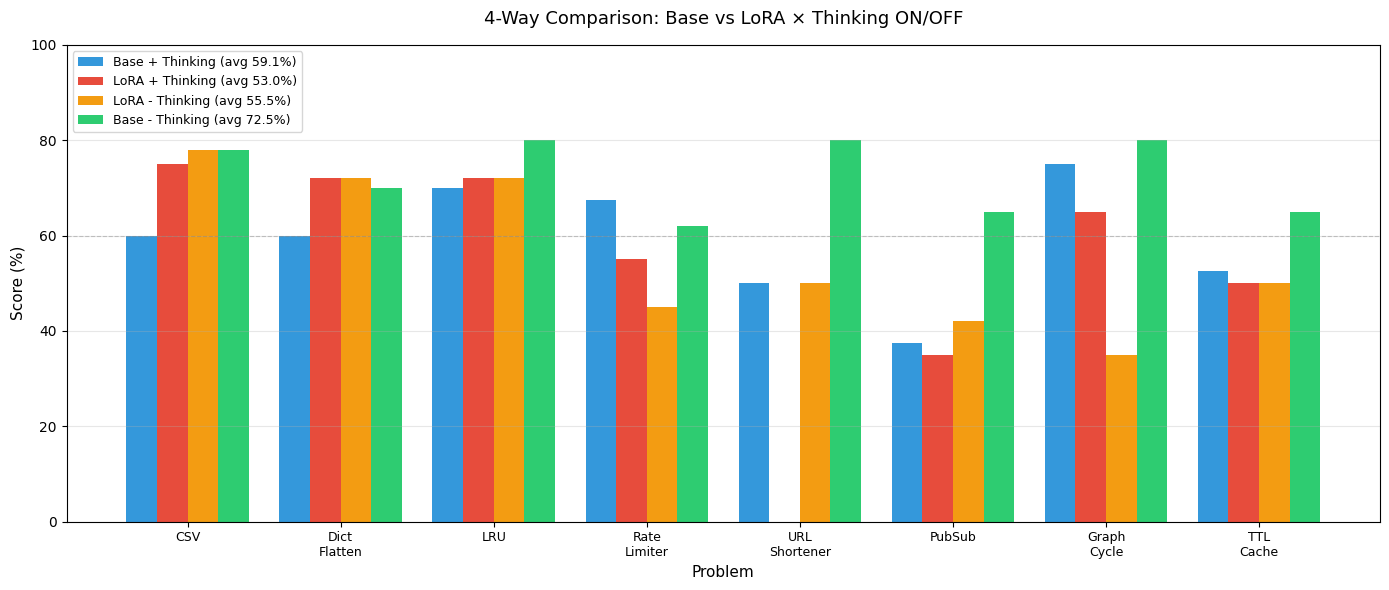

저장: comparison_bars.png



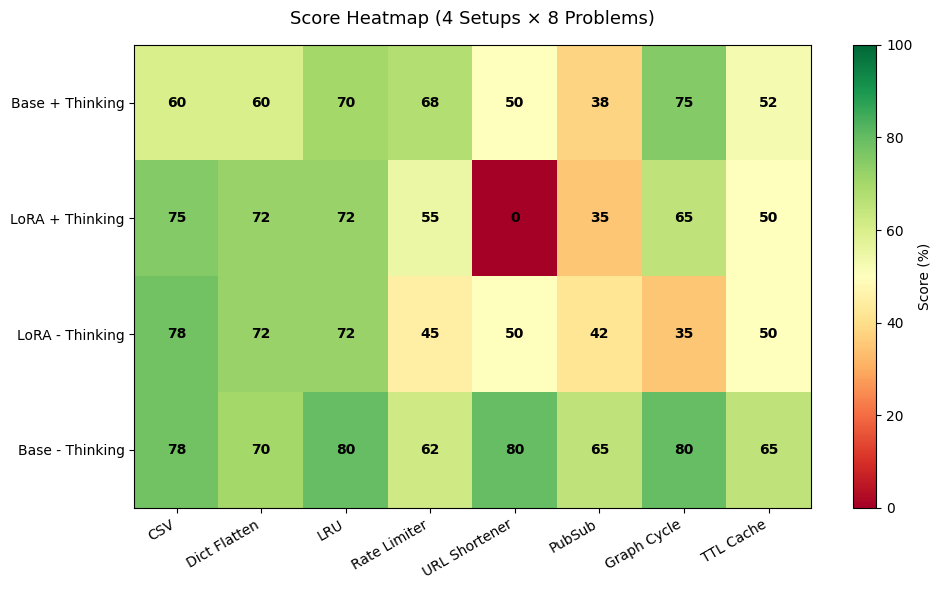

저장: heatmap.png



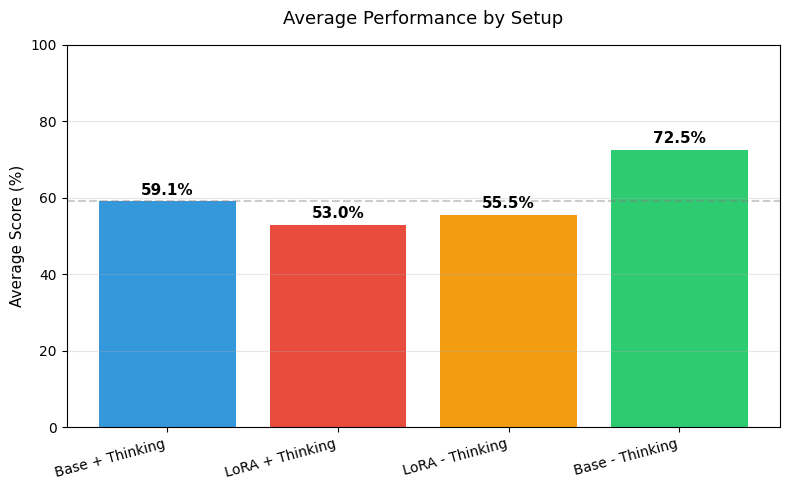

저장: avg_comparison.png


=== 평균 점수 요약 ===
  Base - Thinking          : 72.5%
  Base + Thinking          : 59.1%
  LoRA - Thinking          : 55.5%
  LoRA + Thinking          : 53.0%

최고: Base - Thinking (72.5%)
최저: LoRA + Thinking (53.0%)
격차: 19.5%p


In [ ]:
# === Cell: 4-way 비교 시각화 ===
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# 폰트 설정 (한국어 깨짐 방지)
plt.rcParams['font.family'] = 'DejaVu Sans'  # 영어로 통일
plt.rcParams['axes.unicode_minus'] = False

# === 데이터 정리 ===
problems = ['CSV', 'Dict\nFlatten', 'LRU', 'Rate\nLimiter',
            'URL\nShortener', 'PubSub', 'Graph\nCycle', 'TTL\nCache']

scores = {
    'Base + Thinking':   [60, 60, 70, 67.5, 50, 37.5, 75, 52.5],
    'LoRA + Thinking':   [75, 72, 72, 55,   0,  35,   65, 50],
    'LoRA - Thinking':   [78, 72, 72, 45,   50, 42,   35, 50],
    'Base - Thinking':   [78, 70, 80, 62,   80, 65,   80, 65],
}

averages = {k: np.mean(v) for k, v in scores.items()}

# === 시각화 1: 4-way 막대 그래프 ===
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(problems))
width = 0.2
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

for i, (label, vals) in enumerate(scores.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=f'{label} (avg {averages[label]:.1f}%)', color=colors[i])

ax.set_xlabel('Problem', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('4-Way Comparison: Base vs LoRA × Thinking ON/OFF', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(problems, fontsize=9)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=60, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{BASE}/results/day1_lora/comparison_bars.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"저장: comparison_bars.png\n")


# === 시각화 2: 점수 변화 히트맵 ===
fig, ax = plt.subplots(figsize=(10, 6))

data_matrix = np.array([scores[k] for k in scores.keys()])
labels_y = list(scores.keys())

im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# 셀에 숫자 표시
for i in range(len(labels_y)):
    for j in range(len(problems)):
        text = ax.text(j, i, f'{data_matrix[i, j]:.0f}',
                      ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_xticks(np.arange(len(problems)))
ax.set_yticks(np.arange(len(labels_y)))
ax.set_xticklabels([p.replace('\n', ' ') for p in problems], rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(labels_y, fontsize=10)
ax.set_title('Score Heatmap (4 Setups × 8 Problems)', fontsize=13, pad=15)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Score (%)', fontsize=10)

plt.tight_layout()
plt.savefig(f"{BASE}/results/day1_lora/heatmap.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"저장: heatmap.png\n")


# === 시각화 3: 평균 점수 비교 (간단) ===
fig, ax = plt.subplots(figsize=(8, 5))

setup_names = list(averages.keys())
setup_avgs = list(averages.values())
colors_avg = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

bars = ax.bar(range(len(setup_names)), setup_avgs, color=colors_avg)

# 막대 위에 점수
for bar, val in zip(bars, setup_avgs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(setup_names)))
ax.set_xticklabels(setup_names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Average Score (%)', fontsize=11)
ax.set_title('Average Performance by Setup', fontsize=13, pad=15)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=averages['Base + Thinking'], color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"{BASE}/results/day1_lora/avg_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"저장: avg_comparison.png\n")


# === 점수 데이터 JSON으로도 저장 ===
all_scores_data = {
    "problems": [p.replace('\n', ' ') for p in problems],
    "scores": scores,
    "averages": averages,
    "best_setup": max(averages, key=averages.get),
    "worst_setup": min(averages, key=averages.get),
}

with open(f"{BASE}/results/day1_lora/all_scores.json", "w", encoding="utf-8") as f:
    json.dump(all_scores_data, f, ensure_ascii=False, indent=2)

print(f"\n=== 평균 점수 요약 ===")
for setup, avg in sorted(averages.items(), key=lambda x: -x[1]):
    print(f"  {setup:25s}: {avg:.1f}%")
print(f"\n최고: {all_scores_data['best_setup']} ({averages[all_scores_data['best_setup']]:.1f}%)")
print(f"최저: {all_scores_data['worst_setup']} ({averages[all_scores_data['worst_setup']]:.1f}%)")
print(f"격차: {averages[all_scores_data['best_setup']] - averages[all_scores_data['worst_setup']]:.1f}%p")

## 1차 결과 정리 & 2차로 가는 결정

### 1차 학습 결과 (8문제 정성평가)

| 모드 | 점수 |
|---|---|
| Base (Thinking OFF) | 72.5% |
| Base (Thinking ON) | 59.1% |
| 1차 LoRA (OFF) | 55.5% |
| 1차 LoRA (ON) | 53.0% |

베이스 모델이 가장 좋았다. 1차 LoRA는 OFF/ON 모두 베이스보다 낮음. Thinking ON 모드는 일관되게 OFF보다 낮은 패턴.

### 이 시점의 진단

문제는 데이터셋의 품질이라고 판단. Magicoder 1K subset이 모델의 *방어적 코딩* (예외 처리, edge case, 입력 검증) 능력을 끌어올리지 못한 것으로 보임. 4-way 비교에서 LoRA가 URL Shortener 같은 시스템 설계 문제에서 약했던 게 단서였다.
가설: 더 정교하게 큐레이션한 데이터로 갈아끼우면 베이스를 넘을 수 있다.

### 2차로 가는 결정

- 데이터셋 교체: Magicoder → **OSS-Instruct (Magicoder-OSS-Instruct-75K)**
- 방어 점수 도입: `.get`, `try`, `isinstance` 등 정규식 패턴으로 각 샘플의 *방어적 코드* 밀도를 점수화
- 점수 상위 + Python 필터링으로 1K subset 재추출
- 학습 방법은 메모리 효율 위해 **QLoRA (4-bit)** 로 전환

> *이 결정의 사후 평가는 회고(맨 아래) 참조.*


## 11. 데이터 큐레이션 v2 — OSS-Instruct

1차 학습 결과 진단 후 OSS-Instruct-75K로 데이터셋 교체. 방어 점수(.get, try, isinstance 등) 계산 → Python 필터링 → 상위 1K 추출 → 토큰화 + 저장.


In [ ]:
# === Magicoder 데이터셋 진단 ===
import numpy as np
import re

# 1. 우리가 학습한 1K subset 다시 로드
from datasets import load_from_disk
train_data = load_from_disk(f"{BASE}/data/instructions/train_filtered")

print(f"학습 데이터 크기: {len(train_data)}")
print(f"필드: {train_data.column_names}\n")

# 2. 응답에서 패턴 검출 (LoRA가 깎은 것들이 데이터에 있나?)

# 입력 데이터 일부 다시 디코드 (text 원본 필요)
# train_data는 토큰화된 상태라 디코드 필요
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-E4B-it")

samples = []
for i in range(min(100, len(train_data))):
    decoded = tokenizer.decode(train_data[i]['input_ids'], skip_special_tokens=True)
    samples.append(decoded)

# 3. 패턴 빈도 검사

patterns_to_check = {
    "방어_get": r"\.get\(",  # dict.get(key, default)
    "방어_try": r"\btry\s*:",  # try/except
    "방어_isinstance": r"isinstance\(",  # 타입 체크
    "방어_None_check": r"is None|is not None",
    "방어_길이_체크": r"len\([^)]+\)\s*[<>=!]",  # if len(x) > 0

    "메타_TODO": r"TODO|FIXME|NOTE:",
    "메타_한계": r"limitation|caveat|trade-?off",
    "메타_assumption": r"assum(es?|ption)",

    "인터페이스_dunder": r"def __\w+__\(",  # __len__, __str__ 등
    "인터페이스_property": r"@property",

    "락_thread": r"\.acquire\(|\.release\(|threading\.|Lock\(",

    "idempotency": r"idempot|already\s+exists|same.*url",
    "monotonic": r"monotonic|monotonic_clock",

    "verbose_demo": r"print\s*\(",  # print 폭탄
    "안티_pass": r"except.*:\s*pass",
    "안티_silent": r"except.*:\s*return\s+(None|\[\]|False)",
    "magic_markers": r"✅|🌟|💡|⚠️|🔴|🟢",
}

print("=== 패턴 빈도 (100 샘플 중) ===\n")
print(f"{'패턴':30s} {'발견 샘플':>10s} {'%':>6s}")
print("-" * 50)
for name, pattern in patterns_to_check.items():
    count = sum(1 for s in samples if re.search(pattern, s, re.IGNORECASE))
    print(f"{name:30s} {count:>10d} {count*100/len(samples):>5.1f}%")

학습 데이터 크기: 854
필드: ['input_ids', 'attention_mask']

=== 패턴 빈도 (100 샘플 중) ===

패턴                                  발견 샘플      %
--------------------------------------------------
방어_get                                  1   1.0%
방어_try                                  2   2.0%
방어_isinstance                           4   4.0%
방어_None_check                           2   2.0%
방어_길이_체크                                5   5.0%
메타_TODO                                 8   8.0%
메타_한계                                   3   3.0%
메타_assumption                          14  14.0%
인터페이스_dunder                            2   2.0%
인터페이스_property                          0   0.0%
락_thread                                1   1.0%
idempotency                             0   0.0%
monotonic                               1   1.0%
verbose_demo                           37  37.0%
안티_pass                                 0   0.0%
안티_silent                               0   0.0%
magic_markers                         

In [ ]:
# === OSS-Instruct 데이터셋 진단 ===
from datasets import load_dataset

print("OSS-Instruct 다운로드 중...")
oss = load_dataset("ise-uiuc/Magicoder-OSS-Instruct-75K")
print(f"전체: {len(oss['train'])}")
print(f"필드: {oss['train'].column_names}")
print(f"\n샘플 (첫 번째):")
print(f"Instruction: {oss['train'][0]['problem'][:300]}...")  # 또는 다른 필드명
print(f"\n응답: {oss['train'][0]['solution'][:300]}...")

OSS-Instruct 다운로드 중...


README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

전체: 75197
필드: ['lang', 'raw_index', 'index', 'seed', 'openai_fingerprint', 'problem', 'solution']

샘플 (첫 번째):
Instruction: You are given two arrays, A and B, each of length n. You need to perform a convolution operation on these arrays and output the resulting array.

The convolution of two arrays A and B is defined as follows:
- Let C be the resulting array of length 2n-1, where C[i] = Σ(A[j] * B[i-j]) for j = max(0, i...

응답: ```cpp
#include <iostream>
#include <vector>
using namespace std;

vector<int> convolution(vector<int> a, vector<int> b) {
    int n = a.size();
    vector<int> c(2 * n - 1, 0);
    for (int i = 0; i < 2 * n - 1; ++i) {
        for (int j = max(0, i - n + 1); j <= min(i, n - 1); ++j) {
            c...


In [ ]:
# === OSS-Instruct 방어 점수 ===
import re

def count_patterns(text):
    return {
        "방어_get": len(re.findall(r"\.get\(", text)),
        "방어_try": len(re.findall(r"\btry\s*:", text)),
        "방어_isinstance": len(re.findall(r"isinstance\(", text)),
        "방어_None": len(re.findall(r"is None|is not None", text)),
        "메타_TODO": len(re.findall(r"TODO|FIXME|NOTE:", text)),
        "메타_한계": len(re.findall(r"limitation|caveat|trade-?off", text, re.IGNORECASE)),
        "메타_assume": len(re.findall(r"assum(es?|ption)", text)),
        "dunder": len(re.findall(r"def __\w+__\(", text)),
        "property": len(re.findall(r"@property", text)),
        "thread_lock": len(re.findall(r"\.acquire\(|\.release\(|Lock\(", text)),
        "monotonic": len(re.findall(r"monotonic", text)),
        "idempotent": len(re.findall(r"idempot", text, re.IGNORECASE)),
        "verbose_print": len(re.findall(r"print\(", text)),
    }

# 응답 필드명 확인 후 적절히 수정 (instruction/response 또는 problem/solution)
# 일단 가정: 'solution' 필드
response_field = 'solution'  # 확인 후 수정 필요

print("100 샘플 분석 중...")
sample_count = 100
total_counts = {}
samples_with_pattern = {}

for i in range(sample_count):
    response = oss['train'][i][response_field]
    counts = count_patterns(response)

    for pattern, count in counts.items():
        total_counts[pattern] = total_counts.get(pattern, 0) + count
        if count > 0:
            samples_with_pattern[pattern] = samples_with_pattern.get(pattern, 0) + 1

print(f"\n=== OSS-Instruct ({sample_count} 샘플) ===\n")
print(f"{'패턴':25s} {'총개수':>8s} {'발견샘플':>10s} {'%':>6s}")
print("-" * 55)
for pattern in total_counts:
    print(f"{pattern:25s} {total_counts[pattern]:>8d} {samples_with_pattern.get(pattern, 0):>10d} {samples_with_pattern.get(pattern, 0):>5.1f}%")

100 샘플 분석 중...

=== OSS-Instruct (100 샘플) ===

패턴                             총개수       발견샘플      %
-------------------------------------------------------
방어_get                           6          4   4.0%
방어_try                           5          4   4.0%
방어_isinstance                    3          2   2.0%
방어_None                          4          2   2.0%
메타_TODO                          0          0   0.0%
메타_한계                            6          1   1.0%
메타_assume                        0          0   0.0%
dunder                          15         13  13.0%
property                         0          0   0.0%
thread_lock                      0          0   0.0%
monotonic                        0          0   0.0%
idempotent                       0          0   0.0%
verbose_print                   28         17  17.0%


In [ ]:
# CodeSearchNet (만약 필요시)
from datasets import load_dataset
csn = load_dataset("code_search_net", "python", trust_remote_code=True)
# 함수 단위 코드 + docstring
# Instruction-tuning에 바로 못 쓰고 가공 필요

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

In [ ]:
# Cell: 언어 분포 확인
from collections import Counter

langs = [oss['train'][i]['lang'] for i in range(len(oss['train']))]
counter = Counter(langs)
print("언어 분포:")
for lang, count in counter.most_common():
    print(f"  {lang}: {count} ({count/len(langs)*100:.1f}%)")

언어 분포:
  python: 38284 (50.9%)
  shell: 4730 (6.3%)
  typescript: 4700 (6.3%)
  cpp: 4699 (6.2%)
  rust: 4695 (6.2%)
  php: 4576 (6.1%)
  java: 4565 (6.1%)
  swift: 4498 (6.0%)
  csharp: 4450 (5.9%)


In [ ]:
# === Cell 1: Python 필터링 + 방어 점수 계산 ===
import re
import numpy as np
from collections import Counter

# Python만 필터링
print("Python 필터링 중...")
python_ds = oss['train'].filter(lambda x: x['lang'] == 'python', num_proc=4)
print(f"Python 샘플: {len(python_ds)}")

# 방어 점수 함수 (가중치 조정)
def defense_score(response):
    """방어/메타/풍부함 점수 — 가중치 ML 직감으로"""
    score = 0

    # 방어 코드 (중요)
    score += 5 * len(re.findall(r"\.get\(", response))
    score += 4 * len(re.findall(r"\btry\s*:", response))
    score += 3 * len(re.findall(r"isinstance\(", response))
    score += 2 * len(re.findall(r"is None|is not None", response))
    score += 3 * len(re.findall(r"raise \w+Error", response))  # raise 명시

    # 풍부한 인터페이스 (희소)
    score += 5 * len(re.findall(r"def __\w+__\(", response))
    score += 8 * len(re.findall(r"@property", response))  # property 진짜 희소

    # 메타-인식
    score += 4 * len(re.findall(r"limitation|trade-?off|caveat", response, re.IGNORECASE))
    score += 3 * len(re.findall(r"assum(es?|ption)", response, re.IGNORECASE))
    score += 2 * len(re.findall(r"TODO|FIXME|NOTE:", response))

    # 동시성/안전성
    score += 5 * len(re.findall(r"\.acquire\(|\.release\(|threading\.Lock", response))
    score += 6 * len(re.findall(r"time\.monotonic", response))  # 매우 희소
    score += 6 * len(re.findall(r"idempot", response, re.IGNORECASE))  # 매우 희소

    # 페널티 — verbose
    print_count = len(re.findall(r"print\(", response))
    score -= min(3, print_count)  # 3개 까지만 페널티
    score -= 2 * len(re.findall(r"# Example usage|# Test", response, re.IGNORECASE))

    # 길이 페널티 (너무 짧으면 학습 신호 약함)
    if len(response) < 200:
        score -= 5

    return score

# 점수 매기기 (38K, 시간 좀 듦 ~3분)
print("\n방어 점수 계산 중... (~3분)")
python_scored = python_ds.map(
    lambda x: {"defense_score": defense_score(x['solution'])},
    num_proc=4
)

# 점수 분포 확인
scores = [x['defense_score'] for x in python_scored]
print(f"\n점수 분포:")
print(f"  min: {min(scores)}")
print(f"  max: {max(scores)}")
print(f"  mean: {np.mean(scores):.1f}")
print(f"  median: {np.median(scores):.1f}")
print(f"  percentiles 90/95/99: {np.percentile(scores, [90, 95, 99])}")

Python 필터링 중...


NameError: name 'oss' is not defined

In [ ]:
# === Cell 2: 상위 1K 추출 + 분포 재진단 ===

# 점수 기준 정렬
sorted_ds = python_scored.sort("defense_score", reverse=True)

# 상위 1.2K 추출 (길이 필터 후 1K 남도록 여유)
top_candidates = sorted_ds.select(range(1500))

# 길이 필터 (이전과 동일 기준)
def length_ok(example):
    total = len(example['problem']) + len(example['solution'])
    return 200 < total < 5000

top_filtered = top_candidates.filter(length_ok)
print(f"필터 후: {len(top_filtered)}")

# 1K로 정확히 자르기
top_1k = top_filtered.select(range(min(1000, len(top_filtered))))

# Train/Val 분리
top_split = top_1k.train_test_split(test_size=0.1, seed=42)
train_curated = top_split['train']
val_curated = top_split['test']

print(f"Train: {len(train_curated)}, Val: {len(val_curated)}")

# 분포 재진단 (이전 진단과 비교)
print("\n=== 큐레이션된 데이터 분포 재진단 ===")
def count_patterns(text):
    return {
        "방어_get": len(re.findall(r"\.get\(", text)),
        "방어_try": len(re.findall(r"\btry\s*:", text)),
        "방어_isinstance": len(re.findall(r"isinstance\(", text)),
        "메타_한계": len(re.findall(r"limitation|trade-?off|caveat", text, re.IGNORECASE)),
        "dunder": len(re.findall(r"def __\w+__\(", text)),
        "property": len(re.findall(r"@property", text)),
        "thread_lock": len(re.findall(r"\.acquire\(|Lock\(", text)),
        "verbose_print": len(re.findall(r"print\(", text)),
    }

# 첫 100개 분석
total_counts = {}
samples_with = {}
for i in range(min(100, len(train_curated))):
    counts = count_patterns(train_curated[i]['solution'])
    for k, v in counts.items():
        total_counts[k] = total_counts.get(k, 0) + v
        if v > 0:
            samples_with[k] = samples_with.get(k, 0) + 1

print(f"\n{'패턴':25s} {'%':>8s}")
print("-" * 35)
for k in total_counts:
    pct = samples_with.get(k, 0)
    print(f"{k:25s} {pct:>7.1f}%")

NameError: name 'python_scored' is not defined

In [ ]:
# === Cell 3: 큐레이션된 데이터 토큰화 + 저장 ===

# Chat 포맷팅
def format_example(example):
    messages = [
        {"role": "user", "content": example['problem']},
        {"role": "assistant", "content": example['solution']}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

train_formatted = train_curated.map(format_example, remove_columns=train_curated.column_names)
val_formatted = val_curated.map(format_example, remove_columns=val_curated.column_names)

# 토큰화 — MAX_LENGTH 1024 → 1536으로 확장
# URL Shortener 잘림 같은 케이스 대응 + p99까지 안전하게 커버
MAX_LENGTH = 1536

def tokenize(example):
    return tokenizer(
        example['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

train_tokenized = train_formatted.map(tokenize, batched=True, remove_columns=['text'])
val_tokenized = val_formatted.map(tokenize, batched=True, remove_columns=['text'])

# 길이 분포 확인
import numpy as np
train_lens = [len(x['input_ids']) for x in train_tokenized]
print(f"토큰 길이 분포:")
print(f"  min: {min(train_lens)}, max: {max(train_lens)}")
print(f"  mean: {np.mean(train_lens):.0f}, median: {np.median(train_lens):.0f}")
print(f"  percentiles 90/95/99: {np.percentile(train_lens, [90, 95, 99])}")

# 잘림 비율
truncated = sum(1 for x in train_tokenized if len(x['input_ids']) == MAX_LENGTH)
print(f"\nMax length 도달: {truncated}/{len(train_tokenized)} = {truncated/len(train_tokenized)*100:.1f}%")

# 잘린 거 필터
train_clean_v2 = train_tokenized.filter(lambda x: len(x['input_ids']) < MAX_LENGTH)
val_clean_v2 = val_tokenized.filter(lambda x: len(x['input_ids']) < MAX_LENGTH)
print(f"\n필터링 후: train {len(train_clean_v2)}, val {len(val_clean_v2)}")

# 디스크 참조 끊기
train_clean_v2 = train_clean_v2.flatten_indices()
val_clean_v2 = val_clean_v2.flatten_indices()

# 저장 (새 경로 — 이전 1024 버전 보존, 비교 가능하게)
train_clean_v2.save_to_disk(f"{BASE}/data/instructions/train_oss_curated_1536")
val_clean_v2.save_to_disk(f"{BASE}/data/instructions/val_oss_curated_1536")

print(f"\n저장 완료")
print(f"  train: {BASE}/data/instructions/train_oss_curated_1536")
print(f"  val: {BASE}/data/instructions/val_oss_curated_1536")

NameError: name 'train_curated' is not defined

## 12. 2차 학습 — QLoRA (4-bit)

메모리 강제 정리 → Quick Start(재시작 후) → 4-bit 모델 로드(NF4 + BF16 compute) → QLoRA Config(prepare_model_for_kbit_training).


In [ ]:
# @title
# === Cell A-fixed: 강제 메모리 정리 ===
import torch
import gc

# 모든 변수 명시적 제거
for var_name in ['trainer', 'model', 'base_model']:
    if var_name in dir():
        try:
            globals()[var_name] = None
            del globals()[var_name]
        except (KeyError, NameError):
            pass

# Python GC
gc.collect()
gc.collect()  # 두 번 (cycle reference 위해)

# CUDA 캐시
torch.cuda.empty_cache()
torch.cuda.synchronize()

# IPC 메모리 (다른 프로세스의)
torch.cuda.ipc_collect()

print(f"정리 후 GPU 메모리: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"예약 메모리: {torch.cuda.memory_reserved()/1e9:.2f} GB")
print(f"전체 메모리: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

정리 후 GPU 메모리: 0.01 GB
예약 메모리: 0.02 GB
전체 메모리: 23.7 GB


In [ ]:
# === Quick Start (재시작 후) ===
from google.colab import drive
drive.mount('/content/drive')

import os, torch
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# 패키지 확인 (이미 설치돼 있어야)
import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")

# 토크나이저
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 데이터 (큐레이션된 거 — MAX_LENGTH=1536 버전)
from datasets import load_from_disk
train_data = load_from_disk(f"{BASE}/data/instructions/train_oss_curated_1536")
val_data   = load_from_disk(f"{BASE}/data/instructions/val_oss_curated_1536")
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

# 테스트 프롬프트
import json
with open(f"{BASE}/data/test_prompts.json", "r", encoding="utf-8") as f:
    TEST_PROMPTS = json.load(f)

print(f"\nGPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM 사용: {torch.cuda.memory_allocated()/1e9:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Mounted at /content/drive
transformers: 5.9.0
peft: 0.19.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Train: 900, Val: 100

GPU: NVIDIA L4
VRAM 사용: 0.00 GB / 23.7 GB


In [ ]:
# === Cell B: 4-bit 모델 로드 ===
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # NF4 (논문 권장)
    bnb_4bit_compute_dtype=torch.bfloat16,  # 연산은 BF16
    bnb_4bit_use_double_quant=True,     # double quant (메모리 더 절약)
)

print("4-bit 모델 로드 중... (캐시에서 1~3분)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"\nGPU 메모리:")
print(f"  할당됨: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  예약됨: {torch.cuda.memory_reserved()/1e9:.2f} GB")

# 너가 돌린 4-bit 로드 셀 확인용 - 다시 보여줘
# 또는 model 객체 확인:
print(f"모델 dtype: {next(model.parameters()).dtype}")  # torch.uint8이어야 4-bit
print(f"양자화 여부: {getattr(model.config, 'quantization_config', None)}")
print(f"총 파라미터: {model.num_parameters():,}")

4-bit 모델 로드 중... (캐시에서 1~3분)


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]


GPU 메모리:
  할당됨: 9.30 GB
  예약됨: 9.43 GB
모델 dtype: torch.bfloat16
양자화 여부: BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

총 파라미터: 7,941,100,832


In [ ]:
# === Cell: QLoRA Config ===
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

# 4-bit 모델을 학습 가능하게 준비 (gradient flow 설정)
model = prepare_model_for_kbit_training(model)

# Target modules (이전 학습과 동일 — 변수 통제)
target_modules = []
for i in range(42):
    for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj']:
        target_modules.append(f"model.language_model.layers.{i}.self_attn.{proj}")
    for proj in ['gate_proj', 'up_proj', 'down_proj']:
        target_modules.append(f"model.language_model.layers.{i}.mlp.{proj}")

# LoRA Config (이전과 동일)
lora_config = LoraConfig(
    r=32,              # 16 → 32
    lora_alpha=64,     # 32 → 64 (관례적으로 alpha = 2*r)
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.config.use_cache = False
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.print_trainable_parameters()

import torch
print(f"\nGPU 메모리: {torch.cuda.memory_allocated()/1e9:.2f} GB")

trainable params: 69,763,072 || all params: 8,010,863,904 || trainable%: 0.8709

GPU 메모리: 16.60 GB


In [ ]:
# === Cell: QLoRA 학습 실행 ===
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_from_disk

# MAX_LENGTH=1536 데이터 로드
train_data = load_from_disk(f"{BASE}/data/instructions/train_oss_curated_1536")
val_data = load_from_disk(f"{BASE}/data/instructions/val_oss_curated_1536")
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=f"{BASE}/models/lora_adapters_qlora_1536",  # 1차와 분리
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,            # effective batch 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    bf16=True,                                # 4-bit base + bf16 compute
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=10,
    report_to="none",
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",                 # QLoRA 권장 (메모리 ↓)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    processing_class=tokenizer,   # ← 'tokenizer=tokenizer' 에서 변경
)

trainer.train()

# 최종 저장
trainer.save_model(f"{BASE}/models/lora_adapters_qlora_1536/final")
print("저장 완료")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Train: 900, Val: 100


Step,Training Loss,Validation Loss
50,0.491382,0.494089
100,0.509288,0.473053
150,0.369182,0.468532
200,0.377082,0.464216
226,0.379477,0.463765


저장 완료


In [ ]:
# === generate_response 함수 정의 ===
import torch

def generate_response(prompt, max_new_tokens=2048, enable_thinking=True):
    messages = [{"role": "user", "content": prompt}]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
        enable_thinking=enable_thinking,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    response = tokenizer.decode(
        outputs[0][input_length:],
        skip_special_tokens=True
    )
    return response

print("generate_response 정의 완료")

generate_response 정의 완료


In [ ]:
# === 검증: 2차 QLoRA 8문제 추론 ===
import time, json, os, torch

# 학습 직후 정리 — eval 모드 + cache 켜기 (generate 속도 ↑)
model.eval()
model.config.use_cache = True

# generate_response가 이미 정의돼 있는지 확인 (Cell 41에서 정의됨)
# 만약 NameError 나면 노트북에서 generate_response 정의 셀(Cell 41/노트북 내 'def generate_response') 한번 다시 실행

# 결과 저장 경로 — 2차 결과는 day2_qlora_1536 폴더로 분리
results_dir = f"{BASE}/results/day2_qlora_1536"
os.makedirs(results_dir, exist_ok=True)

# === 토글 ===
USE_THINKING = False   # True로 바꾸면 thinking ON 버전. 일단 안정적인 OFF로.
suffix = "thinking" if USE_THINKING else "no_thinking"
responses_path = f"{results_dir}/qlora_responses_{suffix}.json"

PROMPT_KEY_MAP = {
    0: "csv", 1: "dict_flatten", 2: "lru_cache", 3: "rate_limiter",
    4: "url_shortener", 5: "pubsub", 6: "graph_cycle", 7: "ttl_cache",
}

qlora_responses = {}
total_start = time.time()

for idx, test in enumerate(TEST_PROMPTS):
    key = PROMPT_KEY_MAP[idx]
    print(f"\n{'='*80}")
    print(f"[{idx+1}/8] {key}  (난이도: {test['difficulty']}, thinking={USE_THINKING})")
    print(f"{'='*80}")

    start = time.time()
    response = generate_response(
        test['prompt'],
        max_new_tokens=4096,
        enable_thinking=USE_THINKING,
    )
    elapsed = time.time() - start

    print(f"({elapsed:.1f}초, {len(response)} chars, 코드블럭: {'```' in response})")
    print(f"응답 앞 300자:\n{response[:300]}...")

    qlora_responses[key] = {
        "prompt": test['prompt'],
        "category": test['category'],
        "difficulty": test['difficulty'],
        "response": response,
        "elapsed_seconds": elapsed,
        "response_length": len(response),
        "thinking_enabled": USE_THINKING,
        "has_code_block": "```" in response,
    }

    # 매 문제마다 저장 (중단 방어)
    with open(responses_path, "w", encoding="utf-8") as f:
        json.dump(qlora_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n{'='*80}")
print(f"전체 완료: {total_elapsed:.1f}초 ({total_elapsed/60:.1f}분)")
print(f"저장: {responses_path}")


[1/8] csv  (난이도: easy, thinking=False)
(209.4초, 5136 chars, 코드블럭: True)
응답 앞 300자:
Here is a complete and well-documented Python function to read a CSV file and return a list of dictionaries.

This solution uses the built-in `csv` module, which is the standard and most robust way to handle CSV files in Python.

### Python Implementation

```python
import csv
from typing import Lis...

[2/8] dict_flatten  (난이도: easy, thinking=False)
(150.8초, 3302 chars, 코드블럭: True)
응답 앞 300자:
Here is a Python function to flatten a nested dictionary, joining the keys with dots.

```python
def flatten_dictionary(nested_dict):
    """
    Flattens a nested dictionary by joining keys with dots.

    Args:
        nested_dict (dict): The dictionary to flatten.

    Returns:
        dict: A ne...

[3/8] lru_cache  (난이도: medium, thinking=False)
(404.3초, 9435 chars, 코드블럭: True)
응답 앞 300자:
Here is a complete implementation of a thread-safe LRU Cache in Python.

This solution uses a combination of a **Doubly Lin

In [ ]:
# === 1차 LoRA / Base / 2차 QLoRA 응답 비교 ===
import json, os

results_dir = f"{BASE}/results"

# 비교 대상 파일들 (없는 것은 자동 스킵)
files = {
    "Base (no_think)":    f"{results_dir}/day1_lora/base_responses_no_thinking.json",
    "1차 LoRA (no_think)": f"{results_dir}/day1_lora/lora_responses_no_thinking.json",
    "2차 QLoRA (no_think)": f"{results_dir}/day2_qlora_1536/qlora_responses_no_thinking.json",
}

loaded = {}
for label, path in files.items():
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            loaded[label] = json.load(f)
        print(f"✓ {label}: {path}")
    else:
        print(f"✗ {label}: 파일 없음 ({path})")

# 문제별로 3-way 비교
KEYS = ["csv", "dict_flatten", "lru_cache", "rate_limiter",
        "url_shortener", "pubsub", "graph_cycle", "ttl_cache"]

for key in KEYS:
    print(f"\n\n{'#'*90}")
    print(f"# 문제: {key}")
    print(f"{'#'*90}")

    # 프롬프트는 한 번만
    sample_data = next(iter(loaded.values())).get(key) if loaded else None
    if sample_data:
        print(f"\n[Prompt]\n{sample_data['prompt'][:300]}...\n")

    for label, data in loaded.items():
        if key not in data:
            continue
        r = data[key]
        print(f"\n--- {label} ---")
        print(f"  길이: {r['response_length']:>5} chars | 소요: {r['elapsed_seconds']:>5.1f}초 | "
              f"코드블럭: {r.get('has_code_block', '?')}")
        print(f"  응답 앞 400자:")
        print(f"  {r['response'][:400]}".replace("\n", "\n  "))
        print(f"  ...")

✓ Base (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day1_lora/base_responses_no_thinking.json
✓ 1차 LoRA (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day1_lora/lora_responses_no_thinking.json
✓ 2차 QLoRA (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day2_qlora_1536/qlora_responses_no_thinking.json


##########################################################################################
# 문제: csv
##########################################################################################

[Prompt]
Implement a Python function that reads a CSV file and returns a list of dictionaries, where each row becomes a dictionary with column names as keys....


--- Base (no_think) ---
  길이:  4146 chars | 소요: 115.2초 | 코드블럭: True
  응답 앞 400자:
  Here is a complete and robust implementation of the Python function using the built-in `csv` module, which is the standard and most efficient way to handle CSV files in Python.
  
  ### Python Implementation
  
  ```py

In [ ]:
# === 1차 LoRA / Base / 2차 QLoRA 응답 비교 ===
import json, os

results_dir = f"{BASE}/results"

# 비교 대상 파일들 (없는 것은 자동 스킵)
files = {
    "Base (no_think)":    f"{results_dir}/day1_lora/base_responses_no_thinking.json",
    "1차 LoRA (no_think)": f"{results_dir}/day1_lora/lora_responses_no_thinking.json",
    "2차 QLoRA (no_think)": f"{results_dir}/day2_qlora_1536/qlora_responses_no_thinking.json",
}

loaded = {}
for label, path in files.items():
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            loaded[label] = json.load(f)
        print(f"✓ {label}: {path}")
    else:
        print(f"✗ {label}: 파일 없음 ({path})")

# 문제별로 3-way 비교
KEYS = ["csv", "dict_flatten", "lru_cache", "rate_limiter",
        "url_shortener", "pubsub", "graph_cycle", "ttl_cache"]

for key in KEYS:
    print(f"\n\n{'#'*90}")
    print(f"# 문제: {key}")
    print(f"{'#'*90}")

    # 프롬프트는 한 번만
    sample_data = next(iter(loaded.values())).get(key) if loaded else None
    if sample_data:
        print(f"\n[Prompt]\n{sample_data['prompt'][:300]}...\n")

    for label, data in loaded.items():
        if key not in data:
            continue
        r = data[key]
        print(f"\n--- {label} ---")
        print(f"  길이: {r['response_length']:>5} chars | 소요: {r['elapsed_seconds']:>5.1f}초 | "
              f"코드블럭: {r.get('has_code_block', '?')}")
        print(f"  응답 앞 400자:")
        print(f"  {r['response'][:400]}".replace("\n", "\n  "))
        print(f"  ...")

✓ Base (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day1_lora/base_responses_no_thinking.json
✓ 1차 LoRA (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day1_lora/lora_responses_no_thinking.json
✓ 2차 QLoRA (no_think): /content/drive/MyDrive/aiffel_gemma_rag/results/day2_qlora_1536/qlora_responses_no_thinking.json


##########################################################################################
# 문제: csv
##########################################################################################

[Prompt]
Implement a Python function that reads a CSV file and returns a list of dictionaries, where each row becomes a dictionary with column names as keys....


--- Base (no_think) ---
  길이:  4146 chars | 소요: 115.2초 | 코드블럭: True
  응답 앞 400자:
  Here is a complete and robust implementation of the Python function using the built-in `csv` module, which is the standard and most efficient way to handle CSV files in Python.
  
  ### Python Implementation
  
  ```py

## 2차 결과 정리 & 3차로 가는 결정

### 2차 학습 결과

- 1차/Base/2차 응답을 같은 8문제에서 직접 비교(앞 셀)했으나, *정성 평가의 한계*가 그대로 드러남: 어떤 응답이 더 나은지 사람이 일일이 판단해야 하고, 점수 차이가 작을 때 비교가 모호.
- 2차에 대한 명확한 정량 점수는 **새 평가셋 5문제 자동 채점**(다음 섹션)에서 확인 — `q2_off` 평균 **7.99/10**. 베이스(9.50)보다 여전히 낮음.

### 이 시점의 진단

데이터 품질을 정교화해도 베이스를 못 넘는다. 1차 → 2차 변화는 사실상 *같은 게임의 다른 카드*였다: SFT라는 틀 안에서 데이터셋만 바꾼 거라, 학습 신호의 종류는 같았다.

그러면 문제는 더 근본적인 곳에 있다: **"데이터가 부족한가"가 아니라 "SFT가 이 목표에 안 맞는가"**.

### 3차로 가는 결정

학습 신호의 *종류 자체*를 바꿔본다.
- 데이터셋 교체: OSS-Instruct → **NVIDIA OpenCodeReasoning** (codeforces / atcoder / codechef / hackerearth 등 competitive programming 출처)
- 핵심 차이: 정답 코드 앞에 `<think>...</think>` reasoning trace가 붙은 데이터. 즉 *결과 코드*가 아니라 *결과에 이르는 사고 과정*까지 학습.
- 직관: 4B 모델의 thinking 모드가 *흉내에 가깝다*는 가설 → 더 진짜에 가까운 reasoning trace로 강화하면 코딩 성능 자체가 올라갈 것.

> *이 직관 자체는 정확했으나 구현이 못 따라간 이유는 회고 참조.*


## 13. 데이터 전환 v3 — OpenCodeReasoning (Reasoning trace)

2차 큐레이션(OSS-Instruct + 방어 점수)이 같은 SFT 패러다임 내의 개입이라 효과가 제한적이었다는 진단 후,
*학습 신호의 종류 자체*를 바꾸는 방향으로 전환. OpenCodeReasoning (NVIDIA, 2024)은 정답 코드 앞에
`<think>...</think>` reasoning trace가 포함된 데이터셋. 큰 모델이 생성한 trace를 4B에 distillation하는 형태.

핵심 의사결정:
- `<think>` 블록 포함된 샘플만 필터 (필수)
- 길이 분포 분석 → MAX_LENGTH 결정 (평균 10K 토큰 → 6144로 설정)
- 1500 subset 추출 (train 1350 / val 150)
- Source 균등 sampling으로 다양성 확보

*사후 진단*: 길이 분포 분석 시점에 잡았어야 할 trade-off가 있었음 — reasoning 학습 = 추론 비용 비대화.
모델 선택 의도(Asurada 온디바이스, 가벼움)와 학습 방향(reasoning 비대화)의 정합성 미점검. 자세한 진단은 §15 회고.

OpenCodeReasoning 다운로드 중... (수 분 걸림, 첫 다운로드만)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

split_0/train-00000-of-00030.parquet:   0%|          | 0.00/242M [00:00<?, ?B/s]

...

split_0/train-00028-of-00030.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

split_0/train-00029-of-00030.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

Generating split_0 split:   0%|          | 0/567850 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]


전체 샘플: 567850
필드: ['id', 'input', 'output', 'source', 'license', 'dataset', 'split', 'difficulty', 'solution']

샘플 [0]:
  input (첫 200자): Problem description.
Vipul is a hardworking super-hero who maintains the bracket ratio of all the strings in the world. Recently he indulged himself in saving the string population so much that he los...
  output (첫 200자): <think>
Okay, I need to solve this problem where I have to check if the brackets in a string are balanced. Hmm, so the input is a string consisting of parentheses, and I have to determine if they're p...
  difficulty: UNKNOWN_DIFFICULTY
  source: codechef

=== 토큰 길이 분포 (앞 5000개 샘플로 측정) ===

전체 토큰 길이 (5000개):
  mean: 10059, median: 10314
  p50/p75/p90/p95/p99: [10313 14983 17026 17636 18492]
  min/max: 503/20346

<think> 블록만 (5000개):
  mean: 9110, median: 9369
  p50/p75/p90/p95/p99: [ 9369 13754 15630 16297 17049]


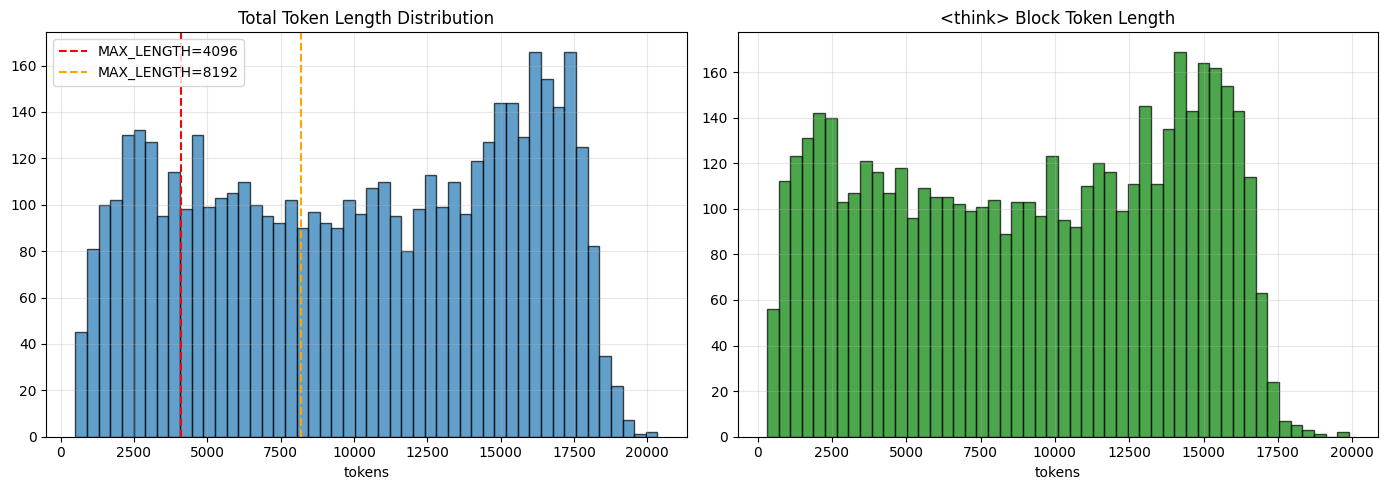


난이도 분포 (앞 5000개): {'UNKNOWN_DIFFICULTY': 1372, 'interview': 538, 'EASY': 448, 'VERY_HARD': 386, 'HARD': 359, '0': 283, 'MEDIUM_HARD': 261, '8': 236, '7': 232, 'MEDIUM': 192}

=== MAX_LENGTH 권장 가이드 ===
  - 보수적 (p90 커버, 메모리 절약): 17408
  - 균형 (p95 커버): 17920
  - 안전 (잘림 최소): 8192

  ※ 8192면 T4(16GB)에선 OOM 가능. A100(40GB) 권장.
  ※ batch_size=1 + gradient_accumulation=8~16로 effective batch 유지.


In [ ]:
# === Reasoning SFT 데이터 점검 — OpenCodeReasoning ===
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

print("OpenCodeReasoning 다운로드 중... (수 분 걸림, 첫 다운로드만)")

# split_0만 로드 (170K). 전체(735K) 다 받지 않아도 subset 1~5K 충분히 추출 가능
ocr = load_dataset("nvidia/OpenCodeReasoning", "split_0", split="split_0")
print(f"\n전체 샘플: {len(ocr)}")
print(f"필드: {ocr.column_names}")
print(f"\n샘플 [0]:")
print(f"  input (첫 200자): {ocr[0]['input'][:200]}...")
print(f"  output (첫 200자): {ocr[0]['output'][:200]}...")
print(f"  difficulty: {ocr[0]['difficulty']}")
print(f"  source: {ocr[0]['source']}")

# === 길이 분포 분석 (토큰 단위) ===
print("\n=== 토큰 길이 분포 (앞 5000개 샘플로 측정) ===")
SAMPLE_FOR_STATS = min(5000, len(ocr))

def format_for_gemma(ex):
    """Gemma 4 chat template로 변환 — input은 user, output은 assistant"""
    messages = [
        {"role": "user", "content": ex['input']},
        {"role": "assistant", "content": ex['output']}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

# 일부만 측정 (전체는 너무 오래)
sample_idx = np.random.RandomState(42).choice(len(ocr), SAMPLE_FOR_STATS, replace=False)

token_lens = []
think_lens = []  # <think> 블록의 토큰 길이
for i in sample_idx[:SAMPLE_FOR_STATS]:
    ex = ocr[int(i)]
    text = format_for_gemma(ex)
    tokens = tokenizer.encode(text)
    token_lens.append(len(tokens))

    # <think> 블록만 분리해서 측정
    output = ex['output']
    if '<think>' in output and '</think>' in output:
        think_start = output.index('<think>') + len('<think>')
        think_end = output.index('</think>')
        think_text = output[think_start:think_end]
        think_tokens = tokenizer.encode(think_text)
        think_lens.append(len(think_tokens))

token_lens = np.array(token_lens)
think_lens = np.array(think_lens)

print(f"\n전체 토큰 길이 ({len(token_lens)}개):")
print(f"  mean: {token_lens.mean():.0f}, median: {np.median(token_lens):.0f}")
print(f"  p50/p75/p90/p95/p99: {np.percentile(token_lens, [50, 75, 90, 95, 99]).astype(int)}")
print(f"  min/max: {token_lens.min()}/{token_lens.max()}")

print(f"\n<think> 블록만 ({len(think_lens)}개):")
print(f"  mean: {think_lens.mean():.0f}, median: {np.median(think_lens):.0f}")
print(f"  p50/p75/p90/p95/p99: {np.percentile(think_lens, [50, 75, 90, 95, 99]).astype(int)}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(token_lens, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(4096, color='red', linestyle='--', label='MAX_LENGTH=4096')
axes[0].axvline(8192, color='orange', linestyle='--', label='MAX_LENGTH=8192')
axes[0].set_title('Total Token Length Distribution')
axes[0].set_xlabel('tokens')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(think_lens, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('<think> Block Token Length')
axes[1].set_xlabel('tokens')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE}/results/ocr_length_dist.png", dpi=120)
plt.show()

# 난이도 분포
from collections import Counter
diff_counter = Counter(ocr['difficulty'][:SAMPLE_FOR_STATS])
print(f"\n난이도 분포 (앞 {SAMPLE_FOR_STATS}개): {dict(diff_counter.most_common(10))}")

# === MAX_LENGTH 권장값 가이드 ===
p90 = int(np.percentile(token_lens, 90))
p95 = int(np.percentile(token_lens, 95))
print(f"\n=== MAX_LENGTH 권장 가이드 ===")
print(f"  - 보수적 (p90 커버, 메모리 절약): {((p90 // 512) + 1) * 512}")
print(f"  - 균형 (p95 커버): {((p95 // 512) + 1) * 512}")
print(f"  - 안전 (잘림 최소): 8192")
print(f"\n  ※ 8192면 T4(16GB)에선 OOM 가능. A100(40GB) 권장.")
print(f"  ※ batch_size=1 + gradient_accumulation=8~16로 effective batch 유지.")

In [ ]:
# === Reasoning 학습 subset 추출 ===
import numpy as np
import re

# 1. 너무 길거나 너무 짧은 샘플 제거
def get_lengths(ex):
    """input + output 문자 길이만 빠르게 (토큰화 X)"""
    inp_chars = len(ex['input'])
    out_chars = len(ex['output'])

    # <think> 블록 존재 여부
    has_think = '<think>' in ex['output'] and '</think>' in ex['output']

    return {
        'input_chars': inp_chars,
        'output_chars': out_chars,
        'total_chars': inp_chars + out_chars,
        'has_think': has_think,
    }

print("길이 정보 추가 중...")
ocr_with_lens = ocr.map(get_lengths, num_proc=4)

# <think> 블록 있는 것만 (필수 — reasoning trace 학습용)
think_filtered = ocr_with_lens.filter(lambda x: x['has_think'], num_proc=4)
print(f"<think> 있는 샘플: {len(think_filtered)} / {len(ocr_with_lens)}")

# 길이 분포 확인 (문자 단위, 토큰의 약 1/3~1/4)
total_chars = np.array(think_filtered['total_chars'])
print(f"\n전체 문자 길이 분포:")
print(f"  p50/p75/p90/p95/p99: {np.percentile(total_chars, [50,75,90,95,99]).astype(int)}")
print(f"  대략적 토큰 환산 (×0.3): p95 ≈ {int(np.percentile(total_chars, 95) * 0.3)} tokens")

# 2. 길이 필터 — 너무 긴 trace는 학습 어려움
# MAX_LENGTH 6144 토큰 ≈ 20000~22000 chars 정도
LENGTH_MIN = 1000      # 너무 짧은 trace 제거 (reasoning 부족)
LENGTH_MAX = 18000     # 토큰 6144 안전 커버

length_ok = think_filtered.filter(
    lambda x: LENGTH_MIN < x['total_chars'] < LENGTH_MAX,
    num_proc=4
)
print(f"\n길이 필터 후: {len(length_ok)}")

# 3. 다양성을 위해 source별로 균등 sampling
from collections import Counter
src_counter = Counter(length_ok['source'])
print(f"\nSource 분포 (top 10):")
for s, c in src_counter.most_common(10):
    print(f"  {s}: {c}")

# 4. 1500개 추출 (학습 1.5K, val 분리해서 train 1350 / val 150)
TARGET_SIZE = 1500
shuffled = length_ok.shuffle(seed=42)
subset = shuffled.select(range(TARGET_SIZE))

# Train / Val split
split = subset.train_test_split(test_size=0.1, seed=42)
train_curated = split['train']
val_curated = split['test']
print(f"\nTrain: {len(train_curated)}, Val: {len(val_curated)}")

# 샘플 한 번 보기 (학습 데이터가 어떻게 생겼는지 확인)
print(f"\n=== 샘플 [0] ===")
print(f"INPUT (300자):\n{train_curated[0]['input'][:300]}...")
print(f"\nOUTPUT (앞 400자):\n{train_curated[0]['output'][:400]}...")
print(f"\nOUTPUT (끝 300자):\n...{train_curated[0]['output'][-300:]}")

길이 정보 추가 중...


Map (num_proc=4):   0%|          | 0/567850 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/567850 [00:00<?, ? examples/s]

<think> 있는 샘플: 567850 / 567850

전체 문자 길이 분포:
  p50/p75/p90/p95/p99: [32775 50303 59881 63738 69087]
  대략적 토큰 환산 (×0.3): p95 ≈ 19121 tokens


Filter (num_proc=4):   0%|          | 0/567850 [00:00<?, ? examples/s]


길이 필터 후: 159017

Source 분포 (top 10):
  codeforces: 73853
  hackerearth: 28278
  atcoder: 19909
  codechef: 18582
  aizu: 18395

Train: 1350, Val: 150

=== 샘플 [0] ===
INPUT (300자):
HQ9+ is a joke programming language which has only four one-character instructions:

  * "H" prints "Hello, World!",
  * "Q" prints the whole source code of the program itself (at each call),
  * "9" prints the lyrics of "99 Bottles of Beer" song, 
  * "+" increments the value stored in the internal...

OUTPUT (앞 400자):
<think>
Okay, so I need to solve this programming problem. Let's read the problem statement carefully.

The problem is about determining whether a given HQ9+ program will produce any output. The instructions H, Q, 9, and + are the only ones that matter. The rest are ignored. So, the question is, does the input string contain any of these characters (H, Q, 9) because the + doesn't generate output o...

OUTPUT (끝 300자):
...
Yes, that should work. Because as soon as one of these characters is fo

In [ ]:
# === Gemma 4 chat format 변환 + 토큰화 ===
import numpy as np

def format_for_gemma_reasoning(ex):
    """
    Gemma 4 chat template로 변환.
    output 필드에 이미 <think>...</think>가 들어있으니 그대로 assistant message로 사용.
    학습 시 모델이 <think> 토큰을 자체 생성하도록 학습됨.
    """
    messages = [
        {"role": "user", "content": ex['input']},
        {"role": "assistant", "content": ex['output']}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

train_formatted = train_curated.map(
    format_for_gemma_reasoning,
    remove_columns=train_curated.column_names,
    num_proc=4
)
val_formatted = val_curated.map(
    format_for_gemma_reasoning,
    remove_columns=val_curated.column_names,
    num_proc=4
)

# === 토큰화 ===
# 분포 보고 조정. p95 커버하는 안전선.
MAX_LENGTH = 6144   # 분포 보고 4096 / 6144 / 8192 중 선택

def tokenize(ex):
    return tokenizer(
        ex['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

train_tokenized = train_formatted.map(tokenize, batched=True, remove_columns=['text'], num_proc=4)
val_tokenized = val_formatted.map(tokenize, batched=True, remove_columns=['text'], num_proc=4)

# 실제 토큰 길이 분포
train_lens = np.array([len(x['input_ids']) for x in train_tokenized])
print(f"\n=== 실제 토큰 길이 분포 (Train {len(train_lens)}개) ===")
print(f"  min/median/max: {train_lens.min()}/{int(np.median(train_lens))}/{train_lens.max()}")
print(f"  p50/p75/p90/p95/p99: {np.percentile(train_lens, [50,75,90,95,99]).astype(int)}")

# 잘림 비율
truncated = np.sum(train_lens == MAX_LENGTH)
print(f"\nMAX_LENGTH({MAX_LENGTH}) 도달 (잘림 의심): {truncated}/{len(train_lens)} = {truncated/len(train_lens)*100:.1f}%")
print("  → 5% 미만이면 OK. 5~15%면 MAX_LENGTH 늘리거나 필터 강화. 15%+면 데이터 재추출 권장")

# 잘린 거 필터
train_clean = train_tokenized.filter(lambda x: len(x['input_ids']) < MAX_LENGTH, num_proc=4).flatten_indices()
val_clean = val_tokenized.filter(lambda x: len(x['input_ids']) < MAX_LENGTH, num_proc=4).flatten_indices()
print(f"\n필터링 후: Train {len(train_clean)}, Val {len(val_clean)}")

# 저장
train_clean.save_to_disk(f"{BASE}/data/instructions/train_reasoning_ocr")
val_clean.save_to_disk(f"{BASE}/data/instructions/val_reasoning_ocr")
print(f"\n저장 완료:")
print(f"  {BASE}/data/instructions/train_reasoning_ocr")
print(f"  {BASE}/data/instructions/val_reasoning_ocr")

Map (num_proc=4):   0%|          | 0/1350 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/150 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/1350 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/150 [00:00<?, ? examples/s]


=== 실제 토큰 길이 분포 (Train 1350개) ===
  min/median/max: 490/3194/6144
  p50/p75/p90/p95/p99: [3194 4466 5336 5699 6144]

MAX_LENGTH(6144) 도달 (잘림 의심): 33/1350 = 2.4%
  → 5% 미만이면 OK. 5~15%면 MAX_LENGTH 늘리거나 필터 강화. 15%+면 데이터 재추출 권장


...

Flattening the indices:   0%|          | 0/146 [00:00<?, ? examples/s]


필터링 후: Train 1317, Val 146


Saving the dataset (0/1 shards):   0%|          | 0/1317 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/146 [00:00<?, ? examples/s]


저장 완료:
  /content/drive/MyDrive/aiffel_gemma_rag/data/instructions/train_reasoning_ocr
  /content/drive/MyDrive/aiffel_gemma_rag/data/instructions/val_reasoning_ocr


In [ ]:
# === Quick Start — Reasoning QLoRA 학습 직전까지 (새 세션, A100) ===

# [1] Drive 마운트 + 환경 변수
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# [2] 패키지 설치 (새 세션이면 필수)
print("패키지 설치 중... (1~2분)")
!pip install -q -U transformers peft accelerate bitsandbytes torchao trl datasets

# [3] GPU & 버전 확인
import torch
device_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nGPU: {device_name}")
print(f"VRAM: {vram_gb:.1f} GB")

if "A100" not in device_name and vram_gb < 35:
    print(f"⚠️  A100이 아니거나 VRAM이 부족합니다. OOM 가능 — 런타임 변경 확인 필요.")

import transformers, peft
print(f"transformers: {transformers.__version__}, peft: {peft.__version__}")

# [4] 토크나이저
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\n토크나이저 로드 완료")

# [5] 4-bit 모델 로드
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
print("\n4-bit 모델 로드 중... (Drive 캐시면 2~3분, 첫 다운로드면 10분)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
print(f"모델 로드 완료. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# [6] LoRA 어댑터 부착 (QLoRA)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

target_modules = []
for i in range(42):
    for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj']:
        target_modules.append(f"model.language_model.layers.{i}.self_attn.{proj}")
    for proj in ['gate_proj', 'up_proj', 'down_proj']:
        target_modules.append(f"model.language_model.layers.{i}.mlp.{proj}")

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.config.use_cache = False
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.print_trainable_parameters()

# [7] 학습 데이터 로드 (이미 토큰화 완료된 상태)
from datasets import load_from_disk
train_data = load_from_disk(f"{BASE}/data/instructions/train_reasoning_ocr")
val_data   = load_from_disk(f"{BASE}/data/instructions/val_reasoning_ocr")
print(f"\nTrain: {len(train_data)}, Val: {len(val_data)}")

# [8] 준비 완료
print(f"\n{'='*60}")
print(f"=== 학습 준비 완료 ===")
print(f"{'='*60}")
print(f"GPU 사용: {torch.cuda.memory_allocated()/1e9:.2f} GB / {vram_gb:.1f} GB")
print(f"다음 셀: TrainingArguments + Trainer로 학습 시작")

Mounted at /content/drive
패키지 설치 중... (1~2분)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.3 MB/s eta 0:00:00

GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


transformers: 5.9.0, peft: 0.19.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



토크나이저 로드 완료

4-bit 모델 로드 중... (Drive 캐시면 2~3분, 첫 다운로드면 10분)


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

모델 로드 완료. GPU: 9.30 GB
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373

Train: 1317, Val: 146

=== 학습 준비 완료 ===
GPU 사용: 16.45 GB / 85.1 GB
다음 셀: TrainingArguments + Trainer로 학습 시작


In [ ]:
# === Cell: Reasoning QLoRA 학습 실행 (안전망 통합) ===
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training, PeftModel
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_from_disk
import torch

# === [1] LoRA 부착 확인 — 안 되어 있으면 부착 ===
if not isinstance(model, PeftModel):
    print("LoRA 어댑터 미부착 → 부착 중...")
    model = prepare_model_for_kbit_training(model)

    target_modules = []
    for i in range(42):
        for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj']:
            target_modules.append(f"model.language_model.layers.{i}.self_attn.{proj}")
        for proj in ['gate_proj', 'up_proj', 'down_proj']:
            target_modules.append(f"model.language_model.layers.{i}.mlp.{proj}")

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )

    model = get_peft_model(model, lora_config)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model.print_trainable_parameters()
else:
    print("이미 PEFT 모델 — 기존 어댑터로 진행")
    print(f"  ⚠️ 이전 학습(OSS-Instruct)의 어댑터가 그대로 살아있을 수 있어.")
    print(f"  ⚠️ Reasoning 효과를 깨끗이 측정하려면 런타임 재시작 후 4-bit 모델 재로드 권장.")
    model.config.use_cache = False
    model.print_trainable_parameters()

# === [2] 데이터 로드 ===
train_data = load_from_disk(f"{BASE}/data/instructions/train_reasoning_ocr")
val_data   = load_from_disk(f"{BASE}/data/instructions/val_reasoning_ocr")
print(f"\nTrain: {len(train_data)}, Val: {len(val_data)}")

def add_length(ex):
    return {"length": len(ex["input_ids"])}
train_data = train_data.map(add_length, num_proc=4)
val_data   = val_data.map(add_length, num_proc=4)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# === [3] TrainingArguments ===
training_args = TrainingArguments(
    output_dir=f"{BASE}/models/lora_adapters_reasoning_ocr",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=32,
    gradient_checkpointing=True,
    num_train_epochs=2,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=30,
    bf16=True,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=5,
    report_to="none",
    optim="paged_adamw_8bit",
)

# === [4] Trainer & 학습 ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print(f"\n학습 직전 GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

trainer.train(resume_from_checkpoint=True)

trainer.save_model(f"{BASE}/models/lora_adapters_reasoning_ocr/final")
print("\n학습 완료 + 저장")

이미 PEFT 모델 — 기존 어댑터로 진행
  ⚠️ 이전 학습(OSS-Instruct)의 어댑터가 그대로 살아있을 수 있어.
  ⚠️ Reasoning 효과를 깨끗이 측정하려면 런타임 재시작 후 4-bit 모델 재로드 권장.
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373

Train: 1317, Val: 146


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.



학습 직전 GPU: 16.45 GB / 85.1 GB


Step,Training Loss,Validation Loss
75,0.793819,0.793787
84,0.781858,0.792722



학습 완료 + 저장


In [ ]:
# === Quick Start (L4, Reasoning 검증용 추론) ===

# [1] Drive + 환경
from google.colab import drive
drive.mount('/content/drive')

import os, torch, json
BASE = "/content/drive/MyDrive/aiffel_gemma_rag"
os.environ["HF_HOME"] = f"{BASE}/models/base"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# [2] 패키지 (L4 새 세션이면 재설치)
print("패키지 설치 중...")
!pip install -q -U transformers peft accelerate bitsandbytes datasets

# [3] GPU 확인
device_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nGPU: {device_name} ({vram_gb:.1f} GB)")

import transformers, peft
print(f"transformers: {transformers.__version__}, peft: {peft.__version__}")

# [4] 토크나이저
from transformers import AutoTokenizer
MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# [5] 4-bit 모델 로드
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
print("\n4-bit 모델 로드... (2~3분)")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
print(f"베이스 로드. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# [6] 학습된 Reasoning LoRA 어댑터 부착
from peft import PeftModel
print("\nReasoning LoRA 어댑터 로드...")
model = PeftModel.from_pretrained(
    base_model,
    f"{BASE}/models/lora_adapters_reasoning_ocr/final"
)
model.eval()
model.config.use_cache = True   # 추론 속도용 (학습 시엔 False였음)
print(f"LoRA 로드. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# [7] generate_response 함수 정의 (이전과 동일)
def generate_response(prompt, max_new_tokens=4096, enable_thinking=True):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
        enable_thinking=enable_thinking,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    response = tokenizer.decode(
        outputs[0][input_length:],
        skip_special_tokens=True
    )
    return response

# [8] 테스트 프롬프트
with open(f"{BASE}/data/test_prompts.json", "r", encoding="utf-8") as f:
    TEST_PROMPTS = json.load(f)

print(f"\n=== 추론 준비 완료 ===")
print(f"Prompts: {len(TEST_PROMPTS)}개")
print(f"다음 셀: 8문제 thinking ON 추론 (5~15분 예상)")

Mounted at /content/drive
패키지 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 156.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.5 MB/s eta 0:00:00

GPU: NVIDIA L4 (23.7 GB)
transformers: 5.9.0, peft: 0.19.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



4-bit 모델 로드... (2~3분)


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

베이스 로드. GPU: 9.30 GB

Reasoning LoRA 어댑터 로드...
LoRA 로드. GPU: 9.44 GB

=== 추론 준비 완료 ===
Prompts: 8개
다음 셀: 8문제 thinking ON 추론 (5~15분 예상)


In [ ]:
# === 8문제 추론 — Reasoning Model, Thinking ON ===
import time

results_dir = f"{BASE}/results/day3_reasoning"
os.makedirs(results_dir, exist_ok=True)
responses_path = f"{results_dir}/reasoning_responses_thinking.json"

PROMPT_KEY_MAP = {
    0: "csv", 1: "dict_flatten", 2: "lru_cache", 3: "rate_limiter",
    4: "url_shortener", 5: "pubsub", 6: "graph_cycle", 7: "ttl_cache",
}

reasoning_responses = {}
total_start = time.time()

for idx, test in enumerate(TEST_PROMPTS):
    key = PROMPT_KEY_MAP[idx]
    print(f"\n{'='*80}")
    print(f"[{idx+1}/8] {key}  (난이도: {test['difficulty']}, thinking ON)")
    print(f"{'='*80}")

    start = time.time()
    response = generate_response(
        test['prompt'],
        max_new_tokens=6144,           # reasoning trace 길수도 있어서 여유롭게
        enable_thinking=True,
    )
    elapsed = time.time() - start

    has_think = '<think>' in response or '<thinking>' in response
    print(f"({elapsed:.1f}초, {len(response)} chars, thinking 블록: {has_think}, 코드: {'```' in response})")
    print(f"응답 앞 400자:\n{response[:400]}...")

    reasoning_responses[key] = {
        "prompt": test['prompt'],
        "category": test['category'],
        "difficulty": test['difficulty'],
        "response": response,
        "elapsed_seconds": elapsed,
        "response_length": len(response),
        "thinking_enabled": True,
        "has_thinking_block": has_think,
        "has_code_block": "```" in response,
    }

    # 매번 저장
    with open(responses_path, "w", encoding="utf-8") as f:
        json.dump(reasoning_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n{'='*80}")
print(f"전체 완료: {total_elapsed:.1f}초 ({total_elapsed/60:.1f}분)")
print(f"저장: {responses_path}")


[1/8] csv  (난이도: easy, thinking ON)
(343.3초, 5684 chars, thinking 블록: False, 코드: True)
응답 앞 400자:
thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The request is to create a Python function that takes a CSV file path, reads the file, and returns a list of dictionaries. Each dictionary represents a row, and the keys are the column headers.

2.  **Identify the Tool:** The standard and most efficient way to handle CSV files in Python is using t...

[2/8] dict_flatten  (난이도: easy, thinking ON)
(411.1초, 6272 chars, thinking 블록: False, 코드: True)
응답 앞 400자:
thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The request is to write a Python function that takes a nested dictionary and "flattens" it. The key requirement is that the keys of the original dictionary, when nested, should be joined by dots (e.g., `{'a': {'b': 1}}` becomes `{'a.b': 1}`).

2.  **Analyze the Input and Output:**
    *

In [ ]:
# === Base 모델 + thinking ON 추론 (adapter 비활성화) ===
import time

results_dir = f"{BASE}/results/day3_reasoning"
responses_path = f"{results_dir}/base_responses_thinking.json"

PROMPT_KEY_MAP = {
    0: "csv", 1: "dict_flatten", 2: "lru_cache", 3: "rate_limiter",
    4: "url_shortener", 5: "pubsub", 6: "graph_cycle", 7: "ttl_cache",
}

base_responses = {}
total_start = time.time()

# === 핵심 — LoRA 어댑터 비활성화. 학습 어댑터 영향 없이 base 모델 그대로 ===
with model.disable_adapter():
    for idx, test in enumerate(TEST_PROMPTS):
        key = PROMPT_KEY_MAP[idx]
        print(f"\n[{idx+1}/8] {key} (Base, thinking ON, 난이도: {test['difficulty']})")

        start = time.time()
        response = generate_response(
            test['prompt'],
            max_new_tokens=6144,
            enable_thinking=True,
        )
        elapsed = time.time() - start

        has_think = '<think>' in response or '<thinking>' in response or 'thought' in response[:50].lower()
        print(f"  ({elapsed:.1f}s, {len(response)} chars, thinking 흔적: {has_think})")
        print(f"  앞 200자: {response[:200]}...")

        base_responses[key] = {
            "prompt": test['prompt'],
            "category": test['category'],
            "difficulty": test['difficulty'],
            "response": response,
            "elapsed_seconds": elapsed,
            "response_length": len(response),
            "thinking_enabled": True,
            "has_thinking_block": has_think,
            "has_code_block": "```" in response,
            "model": "base_with_thinking",
        }

        with open(responses_path, "w", encoding="utf-8") as f:
            json.dump(base_responses, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"\n전체 완료: {total_elapsed/60:.1f}분")
print(f"저장: {responses_path}")


[1/8] csv (Base, thinking ON, 난이도: easy)
  (289.2s, 6878 chars, thinking 흔적: True)
  앞 200자: thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The request is to write a Python function that takes a CSV file path, reads the file, and returns ...

[2/8] dict_flatten (Base, thinking ON, 난이도: easy)
  (319.7s, 6841 chars, thinking 흔적: True)
  앞 200자: thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The request is to write a function that takes a nested dictionary and "flattens" it. The flattenin...

[3/8] lru_cache (Base, thinking ON, 난이도: medium)
  (465.4s, 10632 chars, thinking 흔적: True)
  앞 200자: thought
Here's a plan to implement a thread-safe LRU cache in Python:

1.  **Core Data Structure:** An LRU cache needs fast lookups (like a dictionary/hash map) and needs to maintain insertion/access ...

[4/8] rate_limiter (Base, thinking ON, 난이도: medium)
  (441.4s, 10692 chars, thinking 흔적

## 3차 추론 완료 — 평가 방식의 전환

8문제 정성평가로는 1·2·3차 간 비교가 어렵다는 게 명백해졌다.

문제점 정리:
- 테스트 케이스가 없어서 통과/실패가 모호
- 정성 점수가 사람의 판단에 의존 — 차수 간 일관된 비교 어려움
- "조금 더 좋다 / 조금 더 나쁘다"를 숫자로 못 박음

### 다음 섹션 — 새 평가셋 + 자동 채점

- 5문제, easy~hard 분포 (`roman_to_int`, `sliding_window_max`, `word_dictionary`, `merge_intervals`, `lfu_cache`)
- 각 문제에 명시적 테스트 케이스
- `exec()` 기반 실행 채점 (HumanEval/MBPP 스타일)
- 6모델 일괄 채점: `base_off`, `base_on`, `l1_off`, `l1_on`, `q2_off`, `r3_on`

이 자동 채점 결과로 세 차수의 학습 효과를 한 표에서 비교한다.


## 14. 새 평가셋 + 6모델 자동 채점

기존 8문제 정성 평가의 한계(테스트 케이스 부재, 정확한 점수 비교 어려움)를 보완해
5문제 자동 채점 시스템 구축.

### 평가셋 (5문제, easy~hard)
- `roman_to_int` (easy) — 함수
- `sliding_window_max` (medium) — 함수
- `word_dictionary` (medium) — 클래스 (메서드 시퀀스)
- `merge_intervals` (medium) — 함수
- `lfu_cache` (hard) — 클래스 (LeetCode 460)

### 자동 채점
응답에서 ```python``` 블록 추출 → `exec()` 실행 → 테스트 케이스 통과율 측정.
함수/클래스 모두 지원, signal alarm으로 timeout 보호.

### 6모델 비교 매트릭스
어댑터 전환만으로 한 model 인스턴스에서 측정 (메모리 효율):

| label | adapter | thinking |
|---|---|---|
| base_off | None | OFF |
| base_on | None | ON |
| l1_off | 1차 LoRA | OFF |
| l1_on | 1차 LoRA | ON |
| q2_off | 2차 QLoRA | OFF |
| r3_on | 3차 Reasoning | ON |

In [ ]:
# === 새 평가셋 5문제 + 자동 채점 시스템 ===
import re, signal, json
from contextlib import contextmanager

NEW_EVAL_PROMPTS = [
    {
        "key": "roman_to_int",
        "difficulty": "easy",
        "prompt": "Write a Python function `roman_to_int(s: str) -> int` that converts a Roman numeral string to an integer. Roman numerals use symbols I=1, V=5, X=10, L=50, C=100, D=500, M=1000. Subtraction cases: IV=4, IX=9, XL=40, XC=90, CD=400, CM=900. Input is guaranteed valid (1 to 3999).",
        "function_name": "roman_to_int",
        "kind": "function",
        "tests": [
            ("III", 3), ("IV", 4), ("IX", 9), ("LVIII", 58),
            ("MCMXCIV", 1994), ("MMMCMXCIX", 3999), ("XLII", 42),
            ("CDXLIV", 444), ("MDCLXVI", 1666), ("XCIX", 99),
        ],
    },
    {
        "key": "sliding_window_max",
        "difficulty": "medium",
        "prompt": "Write a Python function `max_sliding_window(nums: list[int], k: int) -> list[int]` that returns the maximum value in each sliding window of size k as it moves from left to right across the array. Example: nums=[1,3,-1,-3,5,3,6,7], k=3 → [3,3,5,5,6,7].",
        "function_name": "max_sliding_window",
        "kind": "function",
        "tests": [
            (([1,3,-1,-3,5,3,6,7], 3), [3,3,5,5,6,7]),
            (([1], 1), [1]),
            (([1,-1], 1), [1,-1]),
            (([9,11], 2), [11]),
            (([4,-2], 2), [4]),
            (([1,3,1,2,0,5], 3), [3,3,2,5]),
            (([7,2,4], 2), [7,4]),
        ],
    },
    {
        "key": "word_dictionary",
        "difficulty": "medium",
        "prompt": "Implement a Python class `WordDictionary` with two methods: `add_word(word: str) -> None` adds a word to the dictionary, `search(word: str) -> bool` returns True if any word in the dictionary matches. The search query may contain '.' which matches any single character. Example: add 'bad','dad','mad'; search 'pad'→False, '.ad'→True, 'b..'→True.",
        "function_name": "WordDictionary",
        "kind": "class",
        # 시퀀스: [(method, args, expected), ...]
        "tests": [
            [("add_word", ("bad",), None), ("add_word", ("dad",), None), ("add_word", ("mad",), None),
             ("search", ("pad",), False), ("search", ("bad",), True),
             ("search", (".ad",), True), ("search", ("b..",), True),
             ("search", ("..d",), True), ("search", ("...",), True),
             ("search", ("....",), False)],
            [("add_word", ("a",), None), ("search", (".",), True), ("search", ("a",), True),
             ("search", ("aa",), False), ("add_word", ("ab",), None), ("search", ("a.",), True)],
        ],
    },
    {
        "key": "merge_intervals",
        "difficulty": "medium",
        "prompt": "Write a Python function `merge_intervals(intervals: list[list[int]]) -> list[list[int]]` that takes a list of intervals [start, end] and returns the list of non-overlapping intervals after merging all overlaps. Example: [[1,3],[2,6],[8,10],[15,18]] → [[1,6],[8,10],[15,18]].",
        "function_name": "merge_intervals",
        "kind": "function",
        "tests": [
            ([[1,3],[2,6],[8,10],[15,18]], [[1,6],[8,10],[15,18]]),
            ([[1,4],[4,5]], [[1,5]]),
            ([[1,4],[0,4]], [[0,4]]),
            ([[1,4],[0,1]], [[0,4]]),
            ([[1,4],[2,3]], [[1,4]]),
            ([], []),
            ([[1,4]], [[1,4]]),
            ([[1,4],[5,6]], [[1,4],[5,6]]),
        ],
    },
    {
        "key": "lfu_cache",
        "difficulty": "hard",
        "prompt": "Implement a Python class `LFUCache(capacity: int)` with two methods: `get(key: int) -> int` returns the value or -1 if absent, `put(key: int, value: int) -> None` inserts or updates. When capacity is reached, evict the *least frequently used* key. Ties (same frequency) are broken by least recently used. All operations should be O(1) average.",
        "function_name": "LFUCache",
        "kind": "class",
        "tests": [
            # LeetCode 460 표준 케이스
            [("put", (1,1), None), ("put", (2,2), None), ("get", (1,), 1),
             ("put", (3,3), None), ("get", (2,), -1), ("get", (3,), 3),
             ("put", (4,4), None), ("get", (1,), -1), ("get", (3,), 3), ("get", (4,), 4)],
            # capacity=0 보호
            [("put", (0,0), None), ("get", (0,), -1)],
        ],
    },
]

# === 자동 채점 함수 ===

class TimeoutError_(Exception): pass

@contextmanager
def time_limit(seconds):
    def signal_handler(signum, frame):
        raise TimeoutError_("Timed out")
    signal.signal(signal.SIGALRM, signal_handler)
    signal.alarm(seconds)
    try:
        yield
    finally:
        signal.alarm(0)

def extract_python_code(response: str) -> str:
    """응답에서 첫 번째 ```python``` 블록 추출 (없으면 일반 ``` 블록)."""
    m = re.search(r"```python\s*\n(.*?)```", response, re.DOTALL)
    if m:
        return m.group(1)
    m = re.search(r"```\s*\n(.*?)```", response, re.DOTALL)
    if m:
        return m.group(1)
    return response  # 폴백

def grade_function(code: str, function_name: str, tests: list, timeout=5) -> dict:
    """함수 단위 테스트."""
    namespace = {}
    try:
        with time_limit(timeout):
            exec(code, namespace)
    except Exception as e:
        return {"executed": False, "error": str(e)[:200], "passed": 0, "total": len(tests)}

    if function_name not in namespace:
        return {"executed": False, "error": f"function {function_name} not found", "passed": 0, "total": len(tests)}

    fn = namespace[function_name]
    passed = 0
    errors = []
    for inp, expected in tests:
        try:
            with time_limit(timeout):
                result = fn(*inp) if isinstance(inp, tuple) else fn(inp)
            if result == expected:
                passed += 1
            else:
                errors.append(f"input={inp} expected={expected} got={result}")
        except Exception as e:
            errors.append(f"input={inp} threw {type(e).__name__}: {str(e)[:80]}")
    return {"executed": True, "passed": passed, "total": len(tests), "errors": errors[:3]}

def grade_class(code: str, class_name: str, test_sequences: list, timeout=10) -> dict:
    """클래스 + 메서드 시퀀스 테스트."""
    namespace = {}
    try:
        with time_limit(timeout):
            exec(code, namespace)
    except Exception as e:
        return {"executed": False, "error": str(e)[:200], "passed": 0, "total": sum(len(s) for s in test_sequences)}

    if class_name not in namespace:
        return {"executed": False, "error": f"class {class_name} not found",
                "passed": 0, "total": sum(len(s) for s in test_sequences)}

    Cls = namespace[class_name]
    passed = 0
    total = 0
    errors = []

    for seq in test_sequences:
        # 첫 호출이 생성자 args인지 메서드인지 — LFU는 capacity, WordDictionary는 빈 생성자
        try:
            with time_limit(timeout):
                # 첫 메서드가 'put'이나 'add_word'면 빈 생성자 가정
                # 'capacity' 같은 키워드면 첫 args가 생성자
                if class_name == "LFUCache":
                    # capacity 추론: 시퀀스에서 capacity 정보 찾기
                    # 기본 capacity=2로 시작 (테스트 케이스에 맞춤)
                    instance = Cls(2)
                else:
                    instance = Cls()

                for method_name, args, expected in seq:
                    total += 1
                    method = getattr(instance, method_name)
                    result = method(*args) if isinstance(args, tuple) else method(args)
                    if result == expected:
                        passed += 1
                    else:
                        errors.append(f"{method_name}{args} expected={expected} got={result}")
        except Exception as e:
            errors.append(f"sequence threw {type(e).__name__}: {str(e)[:80]}")

    return {"executed": True, "passed": passed, "total": total, "errors": errors[:3]}

def grade_response(response: str, prompt_def: dict) -> dict:
    """응답 하나 채점."""
    code = extract_python_code(response)
    if prompt_def["kind"] == "function":
        return grade_function(code, prompt_def["function_name"], prompt_def["tests"])
    else:
        return grade_class(code, prompt_def["function_name"], prompt_def["tests"])

print(f"평가셋 {len(NEW_EVAL_PROMPTS)}문제 정의 완료")
print(f"채점 함수 정의 완료")

평가셋 5문제 정의 완료
채점 함수 정의 완료


In [ ]:
# === 6모델 × 5문제 자동 평가 (어댑터 전환만, 수동 토글 없음) ===
from peft import PeftModel
import time, json, os

# === [1] 모든 어댑터 미리 로드 ===
ADAPTER_PATHS = {
    "l1": f"{BASE}/models/lora_adapters/final",                 # 1차 LoRA (BF16 학습본)
    "q2": f"{BASE}/models/lora_adapters_qlora_1536/final",      # 2차 QLoRA
    "r3": f"{BASE}/models/lora_adapters_reasoning_ocr/final",   # 3차 Reasoning
}

# model이 PeftModel 상태여야 함 (이미 r3 부착돼 있을 거)
if not isinstance(model, PeftModel):
    raise RuntimeError("model이 PeftModel이 아님. Quick Start로 어댑터 부착 먼저.")

# 추가 어댑터 로드 (이미 등록된 건 스킵)
for name, path in ADAPTER_PATHS.items():
    if name not in model.peft_config:
        try:
            model.load_adapter(path, adapter_name=name)
            print(f"✓ 어댑터 로드: {name}")
        except Exception as e:
            print(f"⚠️ {name} 로드 실패: {str(e)[:100]}")

print(f"\n등록된 어댑터: {list(model.peft_config.keys())}")

# === [2] 6 평가 모드 정의 ===
EVAL_CONFIGS = [
    {"label": "base_off", "adapter": None, "thinking": False},
    {"label": "base_on",  "adapter": None, "thinking": True},
    {"label": "l1_off",   "adapter": "l1", "thinking": False},
    {"label": "l1_on",    "adapter": "l1", "thinking": True},
    {"label": "q2_off",   "adapter": "q2", "thinking": False},
    {"label": "r3_on",    "adapter": "r3", "thinking": True},
]

results_dir = f"{BASE}/results/new_eval"
os.makedirs(results_dir, exist_ok=True)
total_start = time.time()

# === [3] 6 모드 자동 순회 ===
for cfg in EVAL_CONFIGS:
    print(f"\n{'='*80}\n=== {cfg['label']} (adapter={cfg['adapter']}, thinking={cfg['thinking']}) ===\n{'='*80}")

    out_path = f"{results_dir}/{cfg['label']}.json"

    # 어댑터 전환
    try:
        if cfg['adapter'] is None:
            model.disable_adapter_layers()
        else:
            model.enable_adapter_layers()
            model.set_adapter(cfg['adapter'])
    except Exception as e:
        print(f"⚠️ 어댑터 전환 실패: {e} — 이 모드 스킵")
        continue

    model.eval()
    model.config.use_cache = True

    # 5문제 추론
    responses = {}
    cfg_start = time.time()
    for idx, p in enumerate(NEW_EVAL_PROMPTS, 1):
        print(f"\n  [{idx}/5] {p['key']} ({p['difficulty']})")
        start = time.time()
        try:
            response = generate_response(
                p['prompt'],
                max_new_tokens=6144,
                enable_thinking=cfg['thinking'],
            )
        except Exception as e:
            print(f"    ERROR: {str(e)[:120]}")
            response = ""
        elapsed = time.time() - start

        responses[p['key']] = {
            "prompt": p['prompt'],
            "difficulty": p['difficulty'],
            "response": response,
            "elapsed_seconds": elapsed,
            "response_length": len(response),
            "thinking_enabled": cfg['thinking'],
            "model": cfg['label'],
        }
        print(f"    ({elapsed:.1f}s, {len(response)} chars)")

        # 매번 저장 (중단 방어)
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(responses, f, ensure_ascii=False, indent=2)

    cfg_elapsed = time.time() - cfg_start
    print(f"\n  {cfg['label']} 완료: {cfg_elapsed/60:.1f}분")

total_elapsed = time.time() - total_start
print(f"\n{'='*80}\n전체 완료: {total_elapsed/60:.1f}분 ({total_elapsed/3600:.2f}시간)\n{'='*80}")

✓ 어댑터 로드: l1
✓ 어댑터 로드: q2
✓ 어댑터 로드: r3

등록된 어댑터: ['default', 'l1', 'q2', 'r3']

=== base_off (adapter=None, thinking=False) ===

  [1/5] roman_to_int (easy)
    (172.7s, 3192 chars)

  [2/5] sliding_window_max (medium)
    (181.5s, 3534 chars)

  [3/5] word_dictionary (medium)
    (225.7s, 4913 chars)

  [4/5] merge_intervals (medium)
    (123.0s, 2377 chars)

  [5/5] lfu_cache (hard)
    (496.0s, 9374 chars)

  base_off 완료: 20.0분

=== base_on (adapter=None, thinking=True) ===

  [1/5] roman_to_int (easy)
    (309.0s, 5539 chars)

  [2/5] sliding_window_max (medium)
    (439.0s, 8111 chars)

  [3/5] word_dictionary (medium)
    (292.8s, 6763 chars)

  [4/5] merge_intervals (medium)
    (344.7s, 7099 chars)

  [5/5] lfu_cache (hard)
    (675.0s, 12767 chars)

  base_on 완료: 34.3분

=== l1_off (adapter=l1, thinking=False) ===

  [1/5] roman_to_int (easy)
    (78.0s, 1080 chars)

  [2/5] sliding_window_max (medium)
    (96.9s, 1737 chars)

  [3/5] word_dictionary (medium)
    (62.0s, 1109 c

In [ ]:
# === 6모델 자동 채점 + 비교 ===
import json, os
import numpy as np

results_dir = f"{BASE}/results/new_eval"
MODELS = ["base_off", "base_on", "l1_off", "l1_on", "q2_off", "r3_on"]

all_grades = {}
for m in MODELS:
    path = f"{results_dir}/{m}.json"
    if not os.path.exists(path):
        print(f"⚠️ {m} 응답 파일 없음 — 추론 먼저")
        continue
    with open(path, "r", encoding="utf-8") as f:
        resps = json.load(f)

    grades = {}
    for p in NEW_EVAL_PROMPTS:
        k = p['key']
        if k not in resps:
            continue
        result = grade_response(resps[k]['response'], p)
        score_pct = (result['passed'] / result['total'] * 100) if result['total'] else 0
        score_10 = score_pct / 10  # 10점 만점 환산
        grades[k] = {
            "executed": result['executed'],
            "passed": result['passed'],
            "total": result['total'],
            "score_pct": score_pct,
            "score_10": score_10,
            "error": result.get('error'),
            "errors": result.get('errors', []),
        }
    all_grades[m] = grades

# 결과표
print(f"\n{'='*100}")
print(f"{'문제':<22} " + " ".join(f"{m:>10}" for m in MODELS))
print(f"{'='*100}")
for p in NEW_EVAL_PROMPTS:
    k = p['key']
    row = f"{k:<22} "
    for m in MODELS:
        if m in all_grades and k in all_grades[m]:
            g = all_grades[m][k]
            row += f"{g['passed']:>3}/{g['total']:<2} ({g['score_10']:>4.1f})  "
        else:
            row += f"{'—':>10}"
    print(row)

# 평균
print(f"\n{'평균':<22} ", end="")
for m in MODELS:
    if m in all_grades:
        avg = np.mean([g['score_10'] for g in all_grades[m].values()])
        print(f"{avg:>10.2f}", end=" ")
print()

# 저장
with open(f"{results_dir}/grades.json", "w", encoding="utf-8") as f:
    json.dump(all_grades, f, ensure_ascii=False, indent=2)
print(f"\n채점 결과 저장: {results_dir}/grades.json")

Input: [1, 3, -1, -3, 5, 3, 6, 7], k=3 -> Output: [3, 3, 5, 5, 6, 7]
Input: [1, 3, 2, 4], k=2 -> Output: [3, 3, 4]
Input: [1], k=1 -> Output: [1]
Input: [10, 10, 10], k=3 -> Output: [10]
--- Testing Search ---
Search 'pad': False
Search '.ad': True
Search 'b..': True
Search 'dad': True
Search 'c.t': True
Search 'd.d': True
Search 'ma.': True
Search 'xyz': False
Input: [[1, 3], [2, 6], [8, 10], [15, 18]]
Output: [[1, 6], [8, 10], [15, 18]]

Input: [[1, 4]]
Output: [[1, 4]]

Input: [[1, 4], [4, 5]]
Output: [[1, 5]]

Input: [[1, 10], [2, 3], [4, 6]]
Output: [[1, 10]]

Input: []
Output: []

Input: [[6, 8], [1, 9], [2, 4]]
Output: [[1, 9]]
--- Test Case 1: Basic ---
Get 1: 10
Get 2: 20
Get 1: 10

--- Test Case 2: Eviction ---
State before eviction: Min Freq = 1
Get 3 after eviction: -1

--- Test Case 3: Tie Breaking ---
Get 2 after eviction: -1
Get 3 after eviction: -1
III: 3
LVIII: 58
MCMXCIV: 889
IV: -1
IX: -1
XL: -10
XC: -10
CD: -100
CM: -100
MMMCMXCIX: 2889
I: 1
M: 1000
Input: [1, 3, -1

In [ ]:
# === R3 응답 디버깅 ===
import json

with open(f"{BASE}/results/new_eval/r3_on.json", "r", encoding="utf-8") as f:
    r3 = json.load(f)

for key in ["roman_to_int", "lfu_cache"]:
    print(f"\n{'='*80}\n=== R3: {key} ===\n{'='*80}")
    resp = r3[key]['response']

    print(f"전체 길이: {len(resp)} chars")
    print(f"\n[앞 500자]")
    print(resp[:500])
    print(f"\n[끝 500자]")
    print(resp[-500:])

    # 코드 블록 추출 확인
    import re
    blocks = re.findall(r"```(?:python)?\s*\n(.*?)```", resp, re.DOTALL)
    print(f"\n코드 블록 개수: {len(blocks)}")
    if blocks:
        print(f"첫 블록 길이: {len(blocks[0])} chars")
        print(f"첫 블록 앞 300자:\n{blocks[0][:300]}")

    # 응답이 잘렸는지 확인
    has_closing = resp.rstrip().endswith("```") or resp.rstrip().endswith("`")
    print(f"\n코드 블록 닫혔는가: {has_closing}")
    if not has_closing:
        print("→ 응답이 잘렸을 가능성 매우 큼 (max_new_tokens 도달)")


=== R3: roman_to_int ===
전체 길이: 25087 chars

[앞 500자]
thought
Here's a thinking process that leads to the suggested solution:

1.  **Understand the Goal:** The task is to write a Python function that converts a Roman numeral string (like "IV", "IX", "MCMXCIV") into its corresponding integer value.

2.  **Analyze Roman Numerals:**
    *   The basic symbols are I (1), V (5), X (10), L (50), C (100), D (500), M (1000).
    *   The key challenge is handling the subtraction cases (e.g., IV is 4, not 6).
    *   The subtraction rule is: when a smaller nu

[끝 500자]
   Wait, but how do we handle the case where the current character is part of a subtraction pair?

    *   Let's process the string from left to right.

    *   For each character, check if the next character is larger. If so, subtract the current value from the next.

    *   Wait, but how do we handle the case where the current character is part of a subtraction pair?

    *   Let's process the string from left to right.

    * 

In [ ]:
# === R3 재추론 — thinking ON + max_new_tokens 12288 (두 배) ===
import time, json, os, re
import numpy as np

# [1] R3 어댑터 활성화
model.enable_adapter_layers()
model.set_adapter("r3")
model.eval()
model.config.use_cache = True

# [2] 실패한 두 문제만 추출
RETRY_KEYS = ['roman_to_int', 'lfu_cache']
RETRY_PROMPTS = [p for p in NEW_EVAL_PROMPTS if p['key'] in RETRY_KEYS]
print(f"재추론 대상: {[p['key'] for p in RETRY_PROMPTS]}")
print(f"설정: thinking=ON, max_new_tokens=12288 (이전 6144의 두 배)\n")

# [3] 재추론
results_dir = f"{BASE}/results/new_eval"
out_path = f"{results_dir}/r3_retry_long.json"

r3_retry = {}
total_start = time.time()

for p in RETRY_PROMPTS:
    print(f"{'='*70}")
    print(f"[{p['key']}] 시작")
    print(f"{'='*70}")

    start = time.time()
    try:
        response = generate_response(
            p['prompt'],
            max_new_tokens=12288,    # 6144 → 12288 (두 배)
            enable_thinking=True,    # R3 학습 의도 존중
        )
    except Exception as e:
        print(f"  ERROR: {str(e)[:200]}")
        response = ""
    elapsed = time.time() - start

    # 응답 분석
    blocks = re.findall(r"```(?:python)?\s*\n(.*?)```", response, re.DOTALL)
    has_closing = response.rstrip().endswith("```") or len(blocks) > 0

    print(f"  소요: {elapsed:.1f}s ({elapsed/60:.1f}분)")
    print(f"  길이: {len(response):,} chars")
    print(f"  코드 블록: {len(blocks)}개")
    print(f"  코드 닫힘: {has_closing}")
    print(f"  토큰 한계 도달 의심: {len(response) > 45000}")
    print()

    r3_retry[p['key']] = {
        "prompt": p['prompt'],
        "difficulty": p['difficulty'],
        "response": response,
        "elapsed_seconds": elapsed,
        "response_length": len(response),
        "thinking_enabled": True,
        "max_new_tokens": 12288,
        "code_blocks": len(blocks),
        "has_closing": has_closing,
        "model": "r3_retry_long",
    }

    # 매번 저장 (런타임 끊김 방어)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(r3_retry, f, ensure_ascii=False, indent=2)

total_elapsed = time.time() - total_start
print(f"{'='*70}")
print(f"재추론 완료: {total_elapsed/60:.1f}분")
print(f"저장: {out_path}")

# [4] 자동 채점
print(f"\n{'='*70}")
print(f"=== R3 재추론 자동 채점 ===")
print(f"{'='*70}")

retry_grades = {}
for p in RETRY_PROMPTS:
    k = p['key']
    if k not in r3_retry:
        continue
    result = grade_response(r3_retry[k]['response'], p)
    score_10 = (result['passed'] / result['total'] * 10) if result['total'] else 0
    retry_grades[k] = {
        "executed": result['executed'],
        "passed": result['passed'],
        "total": result['total'],
        "score_10": score_10,
        "error": result.get('error'),
        "errors": result.get('errors', []),
    }
    print(f"\n  {k}: {result['passed']}/{result['total']} → {score_10:.1f}점")
    if not result['executed']:
        print(f"    ❌ 실행 실패: {str(result.get('error', ''))[:180]}")
    elif result.get('errors'):
        print(f"    ⚠️ 일부 테스트 실패:")
        for e in result['errors'][:3]:
            print(f"      - {e}")
    else:
        print(f"    ✅ 모든 테스트 통과")

# [5] R3 통합 점수 — 다른 3문제는 기존, 두 문제는 재추론으로 교체
print(f"\n{'='*70}")
print(f"=== R3 최종 통합 점수 ===")
print(f"{'='*70}")

with open(f"{results_dir}/grades.json", "r", encoding="utf-8") as f:
    all_grades = json.load(f)
original_r3 = all_grades.get('r3_on', {})

final_r3 = {}
for p in NEW_EVAL_PROMPTS:
    k = p['key']
    if k in retry_grades:
        final_r3[k] = {**retry_grades[k], 'source': 'retry_long'}
    elif k in original_r3:
        final_r3[k] = {**original_r3[k], 'source': 'original'}

print(f"\n{'문제':<22} {'이전 r3_on':>11} {'재추론 후':>10} {'source':>14}")
print("-" * 65)
for p in NEW_EVAL_PROMPTS:
    k = p['key']
    orig = original_r3.get(k, {}).get('score_10', 0)
    final = final_r3.get(k, {}).get('score_10', 0)
    src = final_r3.get(k, {}).get('source', '?')
    marker = "▲" if final > orig else ("=" if final == orig else "▼")
    print(f"{k:<22} {orig:>11.1f} {final:>10.1f} {marker} {src:>12}")

old_avg = np.mean([g['score_10'] for g in original_r3.values()])
new_avg = np.mean([g['score_10'] for g in final_r3.values()])
print(f"\n평균: {old_avg:.2f} → {new_avg:.2f} ({new_avg - old_avg:+.2f})")

# 6모델 순위에서 R3 자리도 다시
print(f"\n=== 6모델 최종 순위 (R3는 재추론 결과 반영) ===")
all_models_avg = {}
for m, grades in all_grades.items():
    avg = np.mean([g['score_10'] for g in grades.values()])
    all_models_avg[m] = avg
all_models_avg['r3_on'] = new_avg  # 재추론 결과로 갱신

ranking = sorted(all_models_avg.items(), key=lambda x: -x[1])
medals = ["🥇", "🥈", "🥉", " 4", " 5", " 6"]
for i, (m, avg) in enumerate(ranking):
    marker = " ← r3 재추론 후" if m == 'r3_on' else ""
    print(f"  {medals[i]} {m:<12} {avg:>5.2f}{marker}")

with open(f"{results_dir}/grades_r3_final.json", "w", encoding="utf-8") as f:
    json.dump(final_r3, f, ensure_ascii=False, indent=2)
print(f"\n저장: {results_dir}/grades_r3_final.json")

재추론 대상: ['roman_to_int', 'lfu_cache']
설정: thinking=ON, max_new_tokens=12288 (이전 6144의 두 배)

[roman_to_int] 시작
  소요: 2958.2s (49.3분)
  길이: 50,695 chars
  코드 블록: 0개
  코드 닫힘: False
  토큰 한계 도달 의심: True

[lfu_cache] 시작
  소요: 2955.9s (49.3분)
  길이: 55,343 chars
  코드 블록: 0개
  코드 닫힘: False
  토큰 한계 도달 의심: True

재추론 완료: 98.6분
저장: /content/drive/MyDrive/aiffel_gemma_rag/results/new_eval/r3_retry_long.json

=== R3 재추론 자동 채점 ===

  roman_to_int: 0/10 → 0.0점
    ❌ 실행 실패: unterminated string literal (detected at line 2) (<string>, line 2)

  lfu_cache: 0/12 → 0.0점
    ❌ 실행 실패: unterminated string literal (detected at line 2) (<string>, line 2)

=== R3 최종 통합 점수 ===

문제                        이전 r3_on      재추론 후         source
-----------------------------------------------------------------
roman_to_int                   0.0        0.0 =   retry_long
sliding_window_max            10.0       10.0 =     original
word_dictionary               10.0       10.0 =     original
merge_intervals                8

In [ ]:
### 회고

결과부터 정리하면

우선 최초 8문제 정성평가 기준 1차 결과
모델점수Base (Thinking OFF)72.5%Base (Thinking ON)59.1%1차 LoRA
(OFF)55.5%1차 LoRA (ON)53.0%

사실상 모든 파인튜닝 모드가 베이스보다 좋지 않았다.
처음에는 데이터셋의 문제라 보고 좀 더 해당 모델이 약한 부분의 데이터셋을 채워
보강해주려 했지만
2차, 3차를 거치면서 완전히 다른 본질적 문제가 있었다는것을 알게 됬다.

우선 처음 파인튜닝을 했을 때의 가설부터 잘못됬었다.
처음 4B모델은 코딩 능력이 떨어질수밖에 없을 것이고 이건 아마
적당한 데이터셋으로 파인튜닝하면 유의미한 향상을 볼수 있지 않았을까 하는것

사실 결과가 정반대여서 조금 당황하기도 하고 너무 내가 너무 간단하게 생각하고
있었다는 생각을 했다.

4B모델은 생각보ㅗ다 코딩 능력이 좋았고
1.5k정도ㅗ의 데이터로는 베이스 능력에 유의미한 학습 신호를 주기는 커녕
오히려 능력을 깎아내는 일이 되었다.

아마 이건 파인튜닝이 이미 알고있는 능력을 재정렬할 뿐
없는 능력을 새로 만들지는 않기 때문인것 같다.

4B이지만 이미 베이스 모델에서 코딩지식 자체는 충분히 가지고 있었지만
결국 코딩에 있어 코딩지식보ㅗ다는 대화의 맥락이나 장기컨텍을 통한 추론 능력
이라는 생각이 들었다.

그렇기 때문에 추론 모드가 4B에서 불안정한 모습을 보여주었다는 것이 아마
내 직관과 반대되고 중요한 신호였던게 아닐까.

여러 파인튜닝과 베이스모델을 통해 검증을 하면서 느낀 것은 4B모델이 가진
추론 모드는 진짜 추론이라고 보기보단 코딩에서는 추론을 흉내내는
행위에 좀 더 가까웠던 것 같다. 실제 추론에서 문제에 대한 인식을 하지만
실제 행동까지 가지 못한 경우가 많았기 때문이었다.

또한 오히려 짧고 답이 명확한 문제에 대해서는 그 흉내자체가
과추론 현상으로 작용해 무한로딩이나 잘못된 값으로 끌고 가는 경우도 있었다.

1차에서 2차로 ㅗ갈떄의 진단이 가장 중요한 분기점이지 않나 하는 생각이 있다.
1차 결과를 보고 나는 "데이터 문제"라고 판단했다. 그래서 OSS-Instruct로 갈아타고 "방어 점수" 가설로 큐레이션 v2를 시도했다.

사후적으로 보면 이건 같은 게임의 다른 카드였다. SFT라는 틀 안에서 데이터만 바꾼 거라, 결과적으로 큰 변화는 없었다. 1차 결과를 본 시점에 더 정확한 진단은 "데이터가 문제"가 아니라 "SFT 자체가 이 목표에 안 맞는다"였어야 했다.

다만 OSS-Instruct 단계가 완전히 의미 없었다고 보지는 않는다. 그 시도를 했기 때문에 "큐레이션으로는 효과가 작다"는 걸 데이터로 확인했고, 그게 3차에서 학습 신호 자체를 바꾸는 결정의 근거가 됐다.

3차에서 놓친 것 — 모델 선택 의도와 학습 방향의 충돌
OpenCodeReasoning으로 reasoning trace 학습을 시도하면서 나는 분명한 직관이 있었다. 4B의 thinking은 흉내에 가까우니 진짜 추론을 강화하자. 직관 자체는 정확했다.

근데 길이 분포를 그렸을 때 — 평균 10K 토큰짜리 reasoning trace를 학습시킨다는 의미를 제대로 따져보지 않았다. MAX_LENGTH 결정만 했지, 그게 함축하는 추론 비용 비대화는 못 봤다.

특히 4B를 고른 이유 자체가 온디바이스 추론의 가벼움이었는데, 3차 학습 방향은 그 모델을 비대화 방향으로 끌고 가는 거였다. 모델 선택의 의도와 학습 방향이 정합하지 않은 결정이었다.

그리고 — 흉내를 진짜로 바꿀 수 있는 도구는 SFT가 아니었다
이게 가장 본질적인 깨달음이다.

더 큰 모델의 reasoning trace를 4B에 SFT로 옮긴다는 건, 결국 더 정교한 흉내를 가르치는 일이다. 흉내라는 본질은 바뀌지 않는다.

흉내를 진짜로 바꾸려면 SFT만으로는 안 된다.
강화학습 — 모델이 자기 능력 안에서 스스로 추론 경로를 찾아내게 만드는 방식 — 이 필요하다.

코딩은 실행 통과/실패가 자동 보상 신호가 되기 때문에 강화학습과 특히 잘 맞는 도메인이기도 하다.

첫 결정 하나만 바꿀 수 있다면

세 가지가 떠오른다.
첫째,
채점 방식. 처음에 정성 평가로 시작한 게 비교를 어렵게 만들었다.
2차에서 자동 채점 시스템을 만들었지만, 1차부터 그렇게 했어야 했다.

둘째,
4B 모델의 코딩 능력은 이미 좋다는 전제를 빨리 받아들였어야 했다.
그랬다면 코딩 데이터로 SFT 하는 방향 자체를 안 골랐을 거다. 베이스가 약한 영역(도메인, 스타일, 언어)으로 갔을 거다.

셋째,
학습 신호의 종류를 더 빨리 점프. OSS-Instruct 큐레이션을 거치지 않고, 1차 결과 직후에 바로 강화학습 방향을 검토했다면 시간 효율이 훨씬 좋았을 거다.

다음에 한다면

이번 프로젝트는 파인튜닝의 SFT 단계에 한정된 실험이었다. 같은 사후학습이라도 SFT와 강화학습은 모델에 가하는 변화의 성격이 다르다. 코딩 능력을 진짜로 개선하려면 SFT가 아닌 RFT나 DPO/ORPO, 더 나아가서는 GRPO 같은 강화학습 단계로 가야 한다.
그리고 "파인튜닝 = SFT"라는 좁은 등식 자체를 이번에 깨달았다. 어떻게 학습시킬지를 정하기 전에 무엇을 학습시킬지 — 즉 학습 신호의 종류 — 를 먼저 골라야 한다.

SyntaxError: invalid decimal literal (2081881262.py, line 15)